# Importing The libraries

In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import hvplot.pandas 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import re
import os

# Data loading

We'll just be loading the unit 5 training and synthetic dataset

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

In [3]:
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

# Splitting the dataframes

The dataframes are split between the time series measured by the sensors ($Y_t$), the control time series ($X_t$) and the operating modes (OP).

#### Helper function to split the data 

In [4]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction and normalization
def create_scaled_sum_feature(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    scaler = MinMaxScaler()
    df[new_feature_name] = scaler.fit_transform(df[[new_feature_name]])
    df.drop(columns=feature_columns, inplace=True)
    return df

def normalize_features(df):
    scaler = MinMaxScaler()
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

In [5]:
def preprocess_hydraulic_data(rds, set_type, operating_conditions):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4: Normalize the control and sensor DataFrames
    control_df = normalize_features(control_df)
    sensors_df = normalize_features(sensors_df)

    # Step 5: Select only the sensor features corresponding to the specified feature group
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    return {
        'control_signals': control_df,
        'sensor_signals': selected_sensor_data
    }

In [6]:
# Example Usage
# Define the operating conditions for turbine steady state
operating_conditions_turbine_steady_state = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_synth, set_type="train", operating_conditions=operating_conditions_turbine_steady_state
)

In [7]:
del rds_u5_synth # To free memory
control_df = rds_u5_turb_ss_volt['control_signals']
sensors_df = rds_u5_turb_ss_volt['sensor_signals']

In [8]:
numb_sensors = 0

for i in range(len(sensors_df)):
    numb_sensors += len(sensors_df[i].columns)

numb_sensors ## A quick sanity check to see if all the columns are kept

75

In [9]:
sensors_voltage_current = sensors_df[0]
sensors_stator_temperature = sensors_df[1]
sensors_cooling_system = sensors_df[2]
sensors_heat_exchanger = sensors_df[3]
sensors_other = sensors_df[4]

In [10]:
### What is the number of time series for each sensor dataframe ?

for i in range(len(sensors_df)):
    print(f"The number of time series is : {len(sensors_df[i].columns)}")

The number of time series is : 14
The number of time series is : 30
The number of time series is : 12
The number of time series is : 9
The number of time series is : 10


In [11]:
def cleaning_control_signals_turbine(df):
    control_df = df
    ### Preprocessing for the turbine mode
    water_opening_columns = control_df.columns[
        control_df.columns.str.startswith("water")]
    
    # Dropping the useless columns
    control_df = control_df.drop(columns=water_opening_columns)
    control_df = control_df.drop(columns="pump_calculated_flow")
    return control_df

In [12]:
control_df = cleaning_control_signals_turbine(control_df)

control_df.shape

(332235, 7)

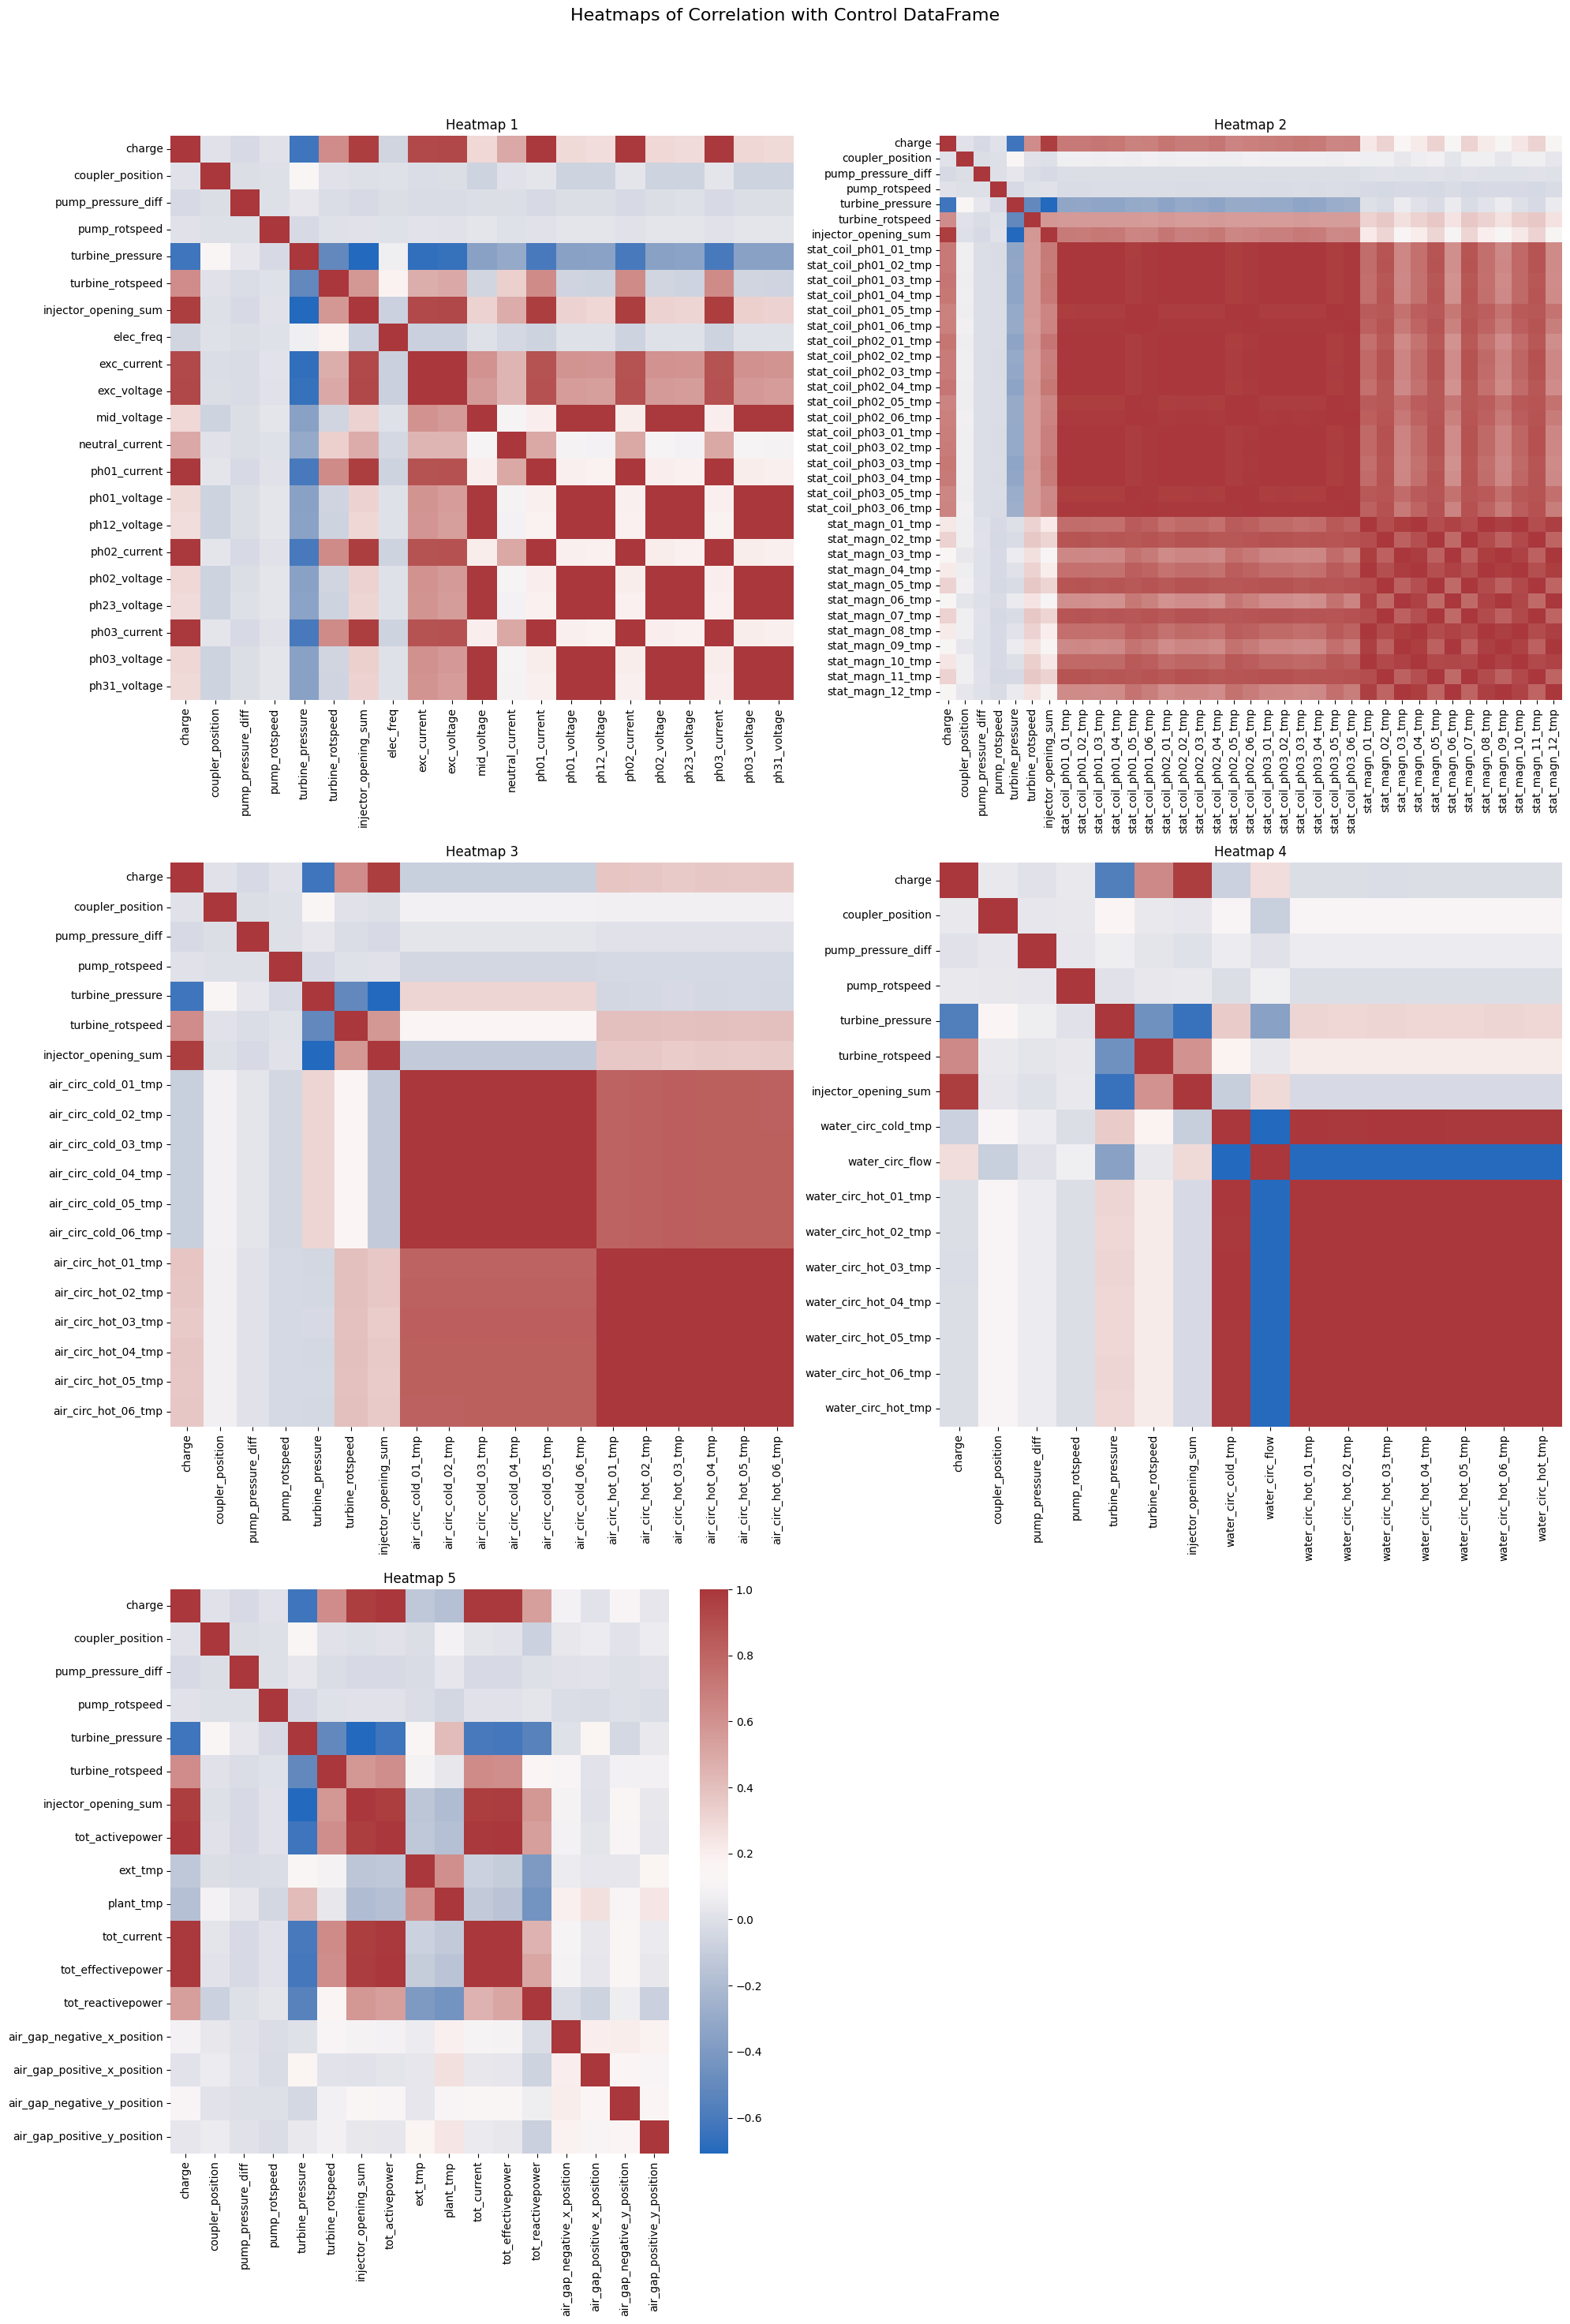

In [13]:
# Set up the subplots with at most 2 plots per row
rows = (len(sensors_df) + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(20, 10 * rows))

for i in range(len(sensors_df)):
    # Determine the subplot location
    row = i // 2
    col = i % 2
    
    # Concatenate control_df with the current sensor DataFrame
    buffer = pd.concat([control_df, sensors_df[i]], axis=1)
    
    # Compute the correlation matrix
    corr_matrix = buffer.corr() ### Could add subsampling
    
    # Plot the heatmap
    sns.heatmap(corr_matrix, cmap="vlag", ax=axs[row, col], cbar=(i == len(sensors_df) - 1))
    axs[row, col].set_title(f"Heatmap {i+1}")

# Remove empty subplots if sensors_df has an odd number of elements
if len(sensors_df) % 2 != 0:
    fig.delaxes(axs[-1, -1])

# Set the overall title
plt.suptitle("Heatmaps of Correlation with Control DataFrame", fontsize=16)

# Adjust the layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plots
plt.show()

In [14]:
# Calculate time differences between consecutive non-NaN values
time_series = control_df['turbine_rotspeed']
valid_data = time_series[time_series.notna()]
time_gaps = valid_data.index.to_series().diff()

# Define threshold for splitting operations
gap_threshold = pd.Timedelta(hours=72)

# Create new groups when gap is larger than threshold
new_operation = (time_gaps > gap_threshold).cumsum()
operation_groups = pd.Series(index=time_series.index, data=None)
operation_groups[valid_data.index] = new_operation

# Assign operation groups to main dataframe
control_df['operation_group'] = operation_groups

# Split into operation periods
operating_periods = []
for group in control_df.groupby('operation_group'):
    if not group[1]['turbine_rotspeed'].isna().all():  # Only keep periods with data
        operating_periods.append(group[1])

# Print info about each period
for i, period in enumerate(operating_periods):
    print(f"Operation Period {i}:")
    print(f"Start: {period.index[0]}")
    print(f"End: {period.index[-1]}")
    print(f"Duration: {period.index[-1] - period.index[0]}")
    print(f"Downtime before next operation: {operating_periods[i+1].index[0] - period.index[-1] if i < len(operating_periods)-1 else 'N/A'}")
    print(f"Number of time samples: {len(period)}\n")

Operation Period 0:
Start: 2020-01-05 07:05:30+01:00
End: 2020-04-01 23:48:30+02:00
Duration: 87 days 15:43:00
Downtime before next operation: 3 days 22:39:30
Number of time samples: 99218

Operation Period 1:
Start: 2020-04-05 22:28:00+02:00
End: 2020-05-30 22:58:30+02:00
Duration: 55 days 00:30:30
Downtime before next operation: 18 days 10:59:00
Number of time samples: 57864

Operation Period 2:
Start: 2020-06-18 09:57:30+02:00
End: 2020-07-30 08:59:00+02:00
Duration: 41 days 23:01:30
Downtime before next operation: 3 days 00:11:30
Number of time samples: 48029

Operation Period 3:
Start: 2020-08-02 09:10:30+02:00
End: 2020-08-13 21:55:30+02:00
Duration: 11 days 12:45:00
Downtime before next operation: 9 days 15:34:30
Number of time samples: 16121

Operation Period 4:
Start: 2020-08-23 13:30:00+02:00
End: 2020-12-09 20:03:30+01:00
Duration: 108 days 07:33:30
Downtime before next operation: 3 days 12:26:00
Number of time samples: 90402

Operation Period 5:
Start: 2020-12-13 08:29:30+0

## Saving the first two operation time

In [15]:
operation_time_0 = operation_groups[operation_groups==0].index

control_op_0_df = control_df.loc[operation_time_0]
control_op_0_df = control_op_0_df.drop(columns="operation_group")
sensors_voltage_current_op_0 = sensors_voltage_current.loc[operation_time_0]
sensors_stator_temperature_op_0 = sensors_stator_temperature.loc[operation_time_0]
sensors_cooling_system_op_0 = sensors_cooling_system.loc[operation_time_0]
sensors_heat_exchanger_op_0 = sensors_heat_exchanger.loc[operation_time_0]
sensors_other_op_0 = sensors_other.loc[operation_time_0]

In [16]:
control_op_0_df.shape

(99218, 7)

In [17]:
save_directory = './preprocessed_dataset/VG5/op_0'

os.makedirs(save_directory, exist_ok=True)

control_op_0_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current_op_0.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature_op_0.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system_op_0.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger_op_0.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other_op_0.to_parquet(path=f'{save_directory}/sensors_other.parquet')

In [18]:
operation_time_1 = operation_groups[operation_groups==1].index

control_op_1_df = control_df.loc[operation_time_1]
control_op_1_df = control_op_1_df.drop(columns="operation_group")
sensors_voltage_current_op_1 = sensors_voltage_current.loc[operation_time_1]
sensors_stator_temperature_op_1 = sensors_stator_temperature.loc[operation_time_1]
sensors_cooling_system_op_1 = sensors_cooling_system.loc[operation_time_1]
sensors_heat_exchanger_op_1 = sensors_heat_exchanger.loc[operation_time_1]
sensors_other_op_1 = sensors_other.loc[operation_time_1]

save_directory = './preprocessed_dataset/VG5/op_1'

os.makedirs(save_directory, exist_ok=True)

control_op_1_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current_op_1.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature_op_1.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system_op_1.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger_op_1.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other_op_1.to_parquet(path=f'{save_directory}/sensors_other.parquet')

## Saving the synthetic dataset

In [34]:
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

rds_u5_turb_ss_volt=preprocess_hydraulic_data(
                                            rds_u5_synth, 
                                            set_type="test_s01",
                                            operating_conditions=operating_conditions_turbine_steady_state
                                        )

del rds_u5_synth # To free memory
control_df = rds_u5_turb_ss_volt['control_signals']
sensors_df = rds_u5_turb_ss_volt['sensor_signals']

control_df = cleaning_control_signals_turbine(control_df)

sensors_voltage_current = sensors_df[0]
sensors_stator_temperature = sensors_df[1]
sensors_cooling_system = sensors_df[2]
sensors_heat_exchanger = sensors_df[3]
sensors_other = sensors_df[4]

save_directory = './preprocessed_dataset/VG5/s_01'

os.makedirs(save_directory, exist_ok=True)

control_df.to_parquet(path=f'{save_directory}/control.parquet')
sensors_voltage_current.to_parquet(path=f'{save_directory}/sensors_voltage_current.parquet')
sensors_stator_temperature.to_parquet(path=f'{save_directory}/sensors_stator_temperature.parquet')
sensors_cooling_system.to_parquet(path=f'{save_directory}/sensors_cooling_system.parquet')
sensors_heat_exchanger.to_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')
sensors_other.to_parquet(path=f'{save_directory}/sensors_other.parquet')

In [20]:
# Load the test dataset for VG5
rds_u5_test = RawDataset(dataset_root, unit="VG5", load_training=False, load_synthetic=True)


In [21]:
# Load the synthetic anomaly datasets
rds_u5_synthetic = RawDataset(dataset_root, unit="VG5", load_training=False, load_synthetic=True)

# Access synthetic test sets
test_s01_info = rds_u5_synthetic.data_dict["test_s01"].info
test_s01_measurements = rds_u5_synthetic.data_dict["test_s01"].measurements


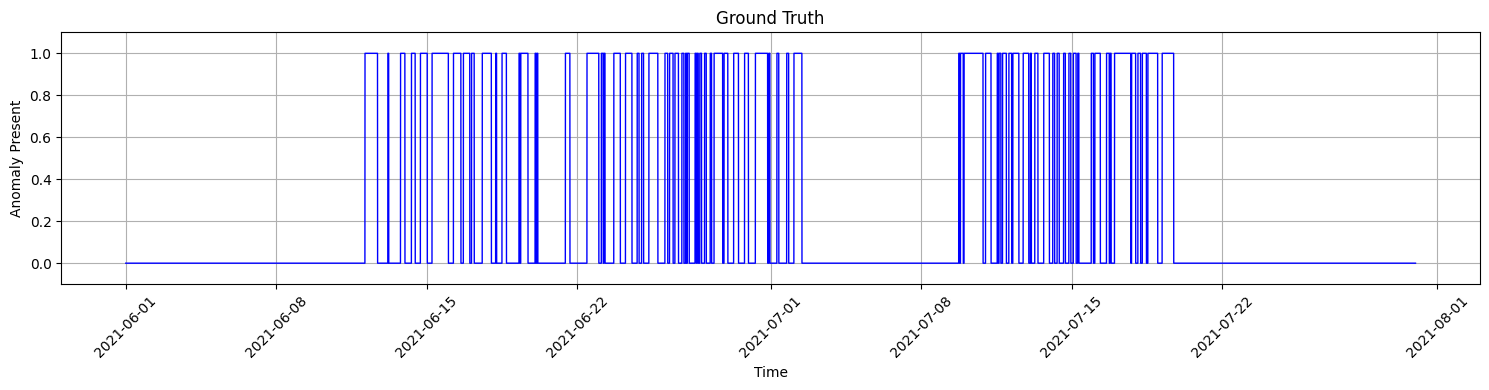

In [156]:
def plot_ground_truth_column(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):
    """
    Plot the dedicated ground_truth column from the anomaly data
    """
    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    
    # Create the plot
    plt.figure(figsize=(15, 4))
    plt.plot(anomaly_data.index, anomaly_data['ground_truth'], 'b-', linewidth=1)
    
    # Customize the plot
    plt.title('Ground Truth')
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics about the ground truth
    anomaly_periods = anomaly_data[anomaly_data['ground_truth'] == 1]

if __name__ == "__main__":
    dataset_root = Path("./dataset")
    plot_ground_truth_column(dataset_root, "VG5", "01", "a")

In [29]:
sensors_cooling_system

,air_circ_cold_01_tmp,air_circ_cold_02_tmp,air_circ_cold_03_tmp,air_circ_cold_04_tmp,air_circ_cold_05_tmp,air_circ_cold_06_tmp,air_circ_hot_01_tmp,air_circ_hot_02_tmp,air_circ_hot_03_tmp,air_circ_hot_04_tmp,air_circ_hot_05_tmp,air_circ_hot_06_tmp
2021-06-01 00:16:00+02:00,0.089063,0.094457,0.096824,0.097083,0.093966,0.094406,0.303957,0.299547,0.298257,0.304625,0.305588,0.303325
2021-06-01 00:16:30+02:00,0.088672,0.094457,0.096434,0.096692,0.093966,0.094406,0.303322,0.298772,0.297680,0.304038,0.304983,0.302559
2021-06-01 00:17:00+02:00,0.088281,0.094457,0.096043,0.096300,0.093966,0.094406,0.302687,0.297997,0.297103,0.303451,0.304379,0.301981
2021-06-01 00:17:30+02:00,0.087891,0.094457,0.095653,0.095909,0.093966,0.094406,0.302052,0.297236,0.296527,0.302864,0.303774,0.301403
2021-06-01 00:18:00+02:00,0.087500,0.094457,0.095262,0.095517,0.093966,0.094406,0.301417,0.296606,0.295950,0.302277,0.303169,0.300825
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-29 22:56:30+02:00,0.601563,0.611212,0.616863,0.610686,0.610776,0.610886,0.746923,0.740150,0.739548,0.742255,0.744784,0.749941
2021-07-29 22:57:00+02:00,0.601563,0.611606,0.616863,0.610686,0.610776,0.611279,0.746340,0.739743,0.739548,0.742255,0.744570,0.749244
2021-07-29 22:57:30+02:00,0.601563,0.611999,0.616863,0.610686,0.610776,0.611672,0.745757,0.739335,0.739548,0.742255,0.744356,0.748547
2021-07-29 22:58:00+02:00,0.601563,0.612393,0.616863,0.610686,0.610776,0.612066,0.745174,0.738927,0.739548,0.742255,0.744142,0.747851


In [102]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import random
import time
from pathlib import Path
import os
from tqdm import tqdm
import matplotlib.pyplot as plt


In [103]:
control_df.head()

,charge,coupler_position,pump_pressure_diff,pump_rotspeed,turbine_pressure,turbine_rotspeed,injector_opening_sum
2021-06-01 00:16:00+02:00,0.652765,0.367457,0.716722,0.357109,0.688147,0.695847,0.450371
2021-06-01 00:16:30+02:00,0.650987,0.367827,0.730725,0.422043,0.682092,0.642237,0.447818
2021-06-01 00:17:00+02:00,0.650411,0.368197,0.744729,0.814255,0.685836,0.628010,0.447109
2021-06-01 00:17:30+02:00,0.649687,0.368566,0.758732,0.214321,0.674603,0.705326,0.442524
2021-06-01 00:18:00+02:00,0.650603,0.368936,0.772736,0.410720,0.686478,0.562364,0.443905


In [142]:
class SlidingWindowDataset(Dataset):
    def __init__(self, control_df, sensor_df, window=50, stride=1, horizon=1, device='cpu'):
        """Sliding window dataset for temperature prediction

        Args:
            control_df (pd.DataFrame): DataFrame containing control signals
            sensor_df (pd.DataFrame): DataFrame containing stator temperature readings
            window (int, optional): sequence window length. Defaults to 50.
            stride (int, optional): data stride length. Defaults to 1.
            horizon (int, optional): prediction forecasting length. Defaults to 1.
        """
        self.window = window
        self.stride = stride
        self.horizon = horizon
        
        # Combine control and sensor data
        self.X = np.concatenate([
            control_df.values,
            sensor_df.values
        ], axis=1).astype(np.float32)
        
        # Target is the sensor temperatures
        self.y = sensor_df.values.astype(np.float32)
        
        # Calculate valid indices for sliding windows
        self.indices = self._get_indices()
        self.indices = torch.from_numpy(self.indices).to(device)

    def _get_indices(self):
        """Calculate valid indices for sliding windows"""
        valid_length = len(self.X) - self.window - self.horizon + 1
        idx_list = [i for i in range(0, valid_length, self.stride)]
        return np.asarray([(idx, idx+self.window) for idx in idx_list])

    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, i):
        i_start, i_stop = self.indices[i]
        x = self.X[i_start:i_stop, :]
        y = self.y[i_stop + self.horizon - 1]  # Target is horizon steps ahead
        x = torch.from_numpy(x).transpose(0, 1)  # Shape: (features, sequence_length)
        y = torch.from_numpy(y)
        return x, y

def create_datasets(control_df, sensor_df, window_size, train_indices, test_indices, device='cpu'):
    """Create train and test datasets"""
    # Split data according to indices
    control_train = control_df.iloc[train_indices]
    sensor_train = sensor_df.iloc[train_indices]
    control_test = control_df.iloc[test_indices]
    sensor_test = sensor_df.iloc[test_indices]
    
    # Create datasets
    train_dataset = SlidingWindowDataset(control_train, sensor_train, window=window_size, device=device)
    test_dataset = SlidingWindowDataset(control_test, sensor_test, window=window_size, device=device)
    
    # Normalize features using training data
    scaler = MinMaxScaler()
    train_dataset.X = scaler.fit_transform(train_dataset.X)
    test_dataset.X = scaler.transform(test_dataset.X)
    
    return train_dataset, test_dataset

def create_data_loaders(dataset, batch_size=256, val_split=0.2):
    """Create train and validation data loaders from a single dataset"""
    # Set random seed for reproducibility
    random.seed(0)
    np.random.seed(0)
    
    # Calculate split
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    split = int(np.floor(val_split * dataset_size))
    
    # Shuffle indices
    np.random.shuffle(indices)
    train_indices, val_indices = indices[split:], indices[:split]
    
    # Create samplers
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(val_indices)
    
    # Create data loaders
    train_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=train_sampler
    )
    val_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=valid_sampler
    )
    
    print(f"\nDataset sizes:")
    print(f"Train: {len(train_indices)}")
    print(f"Validation: {len(val_indices)}")
    
    return train_loader, val_loader

def init_weights(m):
    """Initialize neural network weights"""
    if isinstance(m, nn.BatchNorm1d):
        m.weight.data.fill_(1.0)
        m.bias.data.zero_()
    elif isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
        m.weight.data = nn.init.xavier_uniform_(
            m.weight.data, gain=nn.init.calculate_gain('relu'))
        if m.bias is not None:
            m.bias.data.zero_()

class CNN(nn.Module):
    def __init__(self, 
                 in_channels, 
                 out_channels,
                 window=50, 
                 n_ch=10, 
                 n_k=10, 
                 n_hidden=50, 
                 n_layers=3,
                 dropout=0.0,
                 padding='same',
                 use_batchnorm=False):
        """1D CNN for temperature prediction
        
        Args:
            in_channels: Number of input features (control + sensor variables)
            out_channels: Number of output features (number of temperature sensors)
            window: Sequence length
            n_ch: Number of channels in conv layers
            n_k: Kernel size
            n_hidden: Number of hidden units in final layer
            n_layers: Number of conv layers
            dropout: Dropout rate
            padding: Padding type
            use_batchnorm: Whether to use batch normalization
        """
        super().__init__()
        
        # Create conv layers
        self.conv_layers = nn.ModuleList()
        
        # First layer
        self.conv_layers.append(nn.Sequential(
            nn.Conv1d(in_channels, n_ch, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout)
        ))
        
        # Middle layers
        for _ in range(n_layers - 2):
            self.conv_layers.append(nn.Sequential(
                nn.Conv1d(n_ch, n_ch, kernel_size=n_k, padding=padding),
                nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
                nn.ReLU(),
                nn.Dropout(dropout)
            ))
        
        # Final conv layer
        self.conv_layers.append(nn.Sequential(
            nn.Conv1d(n_ch, n_ch, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(n_ch) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout)
        ))
        
        # Fully connected layers
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_ch * window, n_hidden),
            nn.BatchNorm1d(n_hidden) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, out_channels)
        )
        
        # Initialize weights
        self.apply(init_weights)
        
    def forward(self, x):
        # Pass through conv layers
        for layer in self.conv_layers:
            x = layer(x)
        
        # Pass through regressor
        x = self.regressor(x)
        return x

class Trainer:
    def __init__(
        self,
        model,
        optimizer,
        n_epochs=20,
        criterion=nn.MSELoss(),
        model_name='best_model',
        seed=42,
        device='cpu'
    ):
        self.seed = seed
        self.model = model
        self.optimizer = optimizer
        self.device = device
        self.n_epochs = n_epochs
        self.criterion = criterion
        
        # Create models directory if it doesn't exist
        os.makedirs('models', exist_ok=True)
        
        # Model saving
        time_stamp = time.strftime("%m%d%H%M%S")
        self.model_path = f'models/{model_name}_{time_stamp}.pt'
        
        self.losses = {split: [] for split in ['train', 'eval', 'test']}

    # Add these methods
    def save(self, model, model_path=None):
        """Save model state dict"""
        if model_path is None:
            model_path = self.model_path
        torch.save(model.state_dict(), model_path)
        
    def load(self, model, model_path=None):
        """Load model state dict"""
        if model_path is None:
            model_path = self.model_path
        model.load_state_dict(torch.load(model_path, map_location=self.device))
        print(f"Model loaded from {model_path}")
        return model

    @torch.no_grad()
    def eval_prediction(self, test_loader):
        print("Evaluating predictions...")
        
        try:
            # Load best model
            best_model = self.load(self.model)
            best_model.eval()
            
            preds = []
            trues = []
            
            for x, y in tqdm(test_loader):
                x = x.to(self.device)
                y = y.to(self.device)
                
                y_pred = best_model(x)
                preds.append(y_pred.cpu().numpy())
                trues.append(y.cpu().numpy())
            
            preds = np.concatenate(preds, axis=0)
            trues = np.concatenate(trues, axis=0)
            
            # Create DataFrame for each sensor
            dfs = []
            for sensor_idx in range(preds.shape[1]):
                df = pd.DataFrame({
                    'pred': preds[:, sensor_idx],
                    'true': trues[:, sensor_idx],
                    'error': preds[:, sensor_idx] - trues[:, sensor_idx],
                    'abs_error': np.abs(preds[:, sensor_idx] - trues[:, sensor_idx])
                })
                df['sensor'] = sensor_idx
                dfs.append(df)
            
            df_all = pd.concat(dfs, axis=0)
            
            # Calculate metrics
            overall_rmse = np.sqrt(np.mean((preds - trues) ** 2))
            sensor_rmse = np.sqrt(np.mean((preds - trues) ** 2, axis=0))
            
            df_metrics = pd.DataFrame({
                'sensor': list(range(len(sensor_rmse))) + ['overall'],
                'rmse': np.append(sensor_rmse, overall_rmse)
            })
            
            return df_all, df_metrics
            
        except Exception as e:
            print(f"Error during evaluation: {str(e)}")
            raise

    def compute_loss(self, x, y):
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        return loss, y_pred
    
    def train_epoch(self, loader):
        self.model.train()
        batch_losses = []
        
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            
            loss, _ = self.compute_loss(x, y)
            loss.backward()
            self.optimizer.step()
            
            batch_losses.append(loss.item())
        
        epoch_loss = np.mean(batch_losses)
        self.losses['train'].append(epoch_loss)
        return epoch_loss
    
    @torch.no_grad()
    def eval_epoch(self, loader, split='eval'):
        self.model.eval()
        batch_losses = []
        
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            loss, _ = self.compute_loss(x, y)
            batch_losses.append(loss.item())
        
        epoch_loss = np.mean(batch_losses)
        self.losses[split].append(epoch_loss)
        return epoch_loss
    
    def fit(self, train_loader, val_loader):
        """Train the model"""
        print(f"Training model for {self.n_epochs} epochs...")
        best_val_loss = float('inf')
        
        for epoch in range(self.n_epochs):
            epoch_start = time.time()
            
            # Training phase
            train_loss = self.train_epoch(train_loader)
            
            # Validation phase
            val_loss = self.eval_epoch(val_loader, split='eval')
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(self.model.state_dict(), self.model_path)
            
            epoch_time = time.time() - epoch_start
            print(f"[Epoch {epoch + 1}] "
                  f"train_loss = {train_loss:.5f}, "
                  f"val_loss = {val_loss:.5f} "
                  f"[{epoch_time:.1f}s]")
        
        print("Training completed!")

    @staticmethod
    def calculate_rmse(y_pred, y_true):
        """Calculate RMSE for each sensor and overall"""
        # Overall RMSE
        overall_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
        
        # Per-sensor RMSE
        sensor_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
        
        return overall_rmse, sensor_rmse

    @torch.no_grad()
    def eval_prediction(self, test_loader):
        """Evaluate predictions"""
        print("Evaluating predictions...")
        
        self.model.eval()
        preds = []
        trues = []
        
        for x, y in tqdm(test_loader):
            x = x.to(self.device)
            y = y.to(self.device)
            
            y_pred = self.model(x)
            preds.append(y_pred.cpu().numpy())
            trues.append(y.cpu().numpy())
        
        preds = np.concatenate(preds, axis=0)
        trues = np.concatenate(trues, axis=0)
        
        print(f"Predictions shape: {preds.shape}")
        print(f"True values shape: {trues.shape}")
        
        # Create DataFrame for each sensor
        dfs = []
        for sensor_idx in range(preds.shape[1]):
            df = pd.DataFrame({
                'pred': preds[:, sensor_idx],
                'true': trues[:, sensor_idx],
                'error': preds[:, sensor_idx] - trues[:, sensor_idx],
                'abs_error': np.abs(preds[:, sensor_idx] - trues[:, sensor_idx]),
                'sensor': sensor_idx  # Add sensor column
            })
            dfs.append(df)
        
        # Combine all sensor DataFrames
        df_all = pd.concat(dfs, axis=0, ignore_index=True)
        
        # Calculate RMSE
        overall_rmse = np.sqrt(np.mean((preds - trues) ** 2))
        sensor_rmse = np.sqrt(np.mean((preds - trues) ** 2, axis=0))
        
        df_metrics = pd.DataFrame({
            'sensor': list(range(len(sensor_rmse))) + ['overall'],
            'rmse': np.append(sensor_rmse, overall_rmse)
        })
        
        print("\nDataFrame shape:", df_all.shape)
        print("DataFrame columns:", df_all.columns.tolist())
        
        return df_all, df_metrics

    def plot_predictions(self, df_test, n_sensors=None):
        """Plot predictions vs true values for each sensor"""
        if n_sensors is None:
            n_sensors = df_test['sensor'].nunique()
        
        n_cols = 3
        n_rows = (n_sensors + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        axes = axes.flatten()
        
        for sensor_idx in range(n_sensors):
            ax = axes[sensor_idx]
            sensor_data = df_test[df_test['sensor'] == sensor_idx]
            
            # Plot predictions and true values
            ax.plot(sensor_data['true'], label='True', color='blue', alpha=0.6)
            ax.plot(sensor_data['pred'], label='Predicted', color='red', alpha=0.6)
            
            # Plot error band
            ax.fill_between(
                sensor_data.index,
                sensor_data['true'],
                sensor_data['pred'],
                alpha=0.2,
                color='gray',
                label='Error'
            )
            
            # Add RMSE to title
            rmse = np.sqrt(np.mean(sensor_data['abs_error']**2))
            ax.set_title(f'Sensor {sensor_idx} (RMSE: {rmse:.4f})')
            ax.grid(True, linestyle='--', alpha=0.7)
            if sensor_idx == 0:
                ax.legend()
        
        # Remove empty subplots
        for idx in range(sensor_idx + 1, len(axes)):
            fig.delaxes(axes[idx])
        
        plt.suptitle('Temperature Predictions for Each Sensor', y=1.02)
        plt.tight_layout()
        plt.show()

# Usage example
def train_temperature_predictor(control_df, sensor_df, train_indices, test_indices):
    # Set random seed
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    
    # Parameters
    params = {
        'window': 50,
        'batch_size': 256,
        'n_epochs': 50,
        'lr': 1e-3,
        'weight_decay': 1e-5
    }
    
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Create datasets
    datasets = create_datasets(
        control_df, 
        sensor_df,
        window_size=params['window'],
        train_indices=train_indices,
        test_indices=test_indices,
        device=device
    )
    
    # Create dataloaders
    loaders = create_data_loaders(datasets, batch_size=params['batch_size'])
    
    # Initialize model
    model = CNN(
        in_channels=control_df.shape[1] + sensor_df.shape[1],
        out_channels=sensor_df.shape[1],
        window=params['window']
    ).to(device)
    
    # Initialize optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    
    # Initialize trainer
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        n_epochs=params['n_epochs'],
        device=device
    )
    
    # Train model
    trainer.fit(loaders)
    
    return trainer, model

## Start training the 1D CNN

In [143]:
def setup_training(selected_sensor_group='stator_temperature', params=DEFAULT_PARAMS):
    """Setup training with selected sensor group"""
    print(f"\nSetting up training for {selected_sensor_group}")
    print(f"Input channels: {params['in_channels']}")
    print(f"Output channels: {params['out_channels']}")
    
    # Create normalizer
    normalizer = DataNormalizer()

    # Print ranges before normalization
    print("\nBefore normalization:")
    print(f"Control data range: {control_df.min().min():.3f} to {control_df.max().max():.3f}")
    print(f"Sensor data range: {SENSOR_GROUPS[selected_sensor_group].min().min():.3f} to {SENSOR_GROUPS[selected_sensor_group].max().max():.3f}")
    
    # Normalize data
    control_norm, sensor_norm = normalizer.fit_transform(
        control_df, 
        SENSOR_GROUPS[selected_sensor_group]
    )

    # Print ranges after normalization
    print("\nAfter normalization:")
    print(f"Control data range: {control_norm.min().min():.3f} to {control_norm.max().max():.3f}")
    print(f"Sensor data range: {sensor_norm.min().min():.3f} to {sensor_norm.max().max():.3f}")

    # Create dataset
    dataset = SlidingWindowDataset(
        control_norm,
        sensor_norm,
        window=params['window']
    )
    
    # Create loaders
    train_loader, val_loader = create_data_loaders(
        dataset,
        batch_size=params['batch_size'],
        val_split=0.2
    )
    
    return train_loader, val_loader, normalizer

# And let's make sure we have the DataNormalizer class defined:
class DataNormalizer:
    def __init__(self):
        self.control_scaler = MinMaxScaler()
        self.sensor_scaler = MinMaxScaler()
        
    def fit_transform(self, control_df, sensor_df):
        """Fit scalers and transform training data"""
        control_normalized = pd.DataFrame(
            self.control_scaler.fit_transform(control_df),
            columns=control_df.columns,
            index=control_df.index
        )
        
        sensor_normalized = pd.DataFrame(
            self.sensor_scaler.fit_transform(sensor_df),
            columns=sensor_df.columns,
            index=sensor_df.index
        )
        
        return control_normalized, sensor_normalized
    
    def transform(self, control_df, sensor_df):
        """Transform test data using fitted scalers"""
        control_normalized = pd.DataFrame(
            self.control_scaler.transform(control_df),
            columns=control_df.columns,
            index=control_df.index
        )
        
        sensor_normalized = pd.DataFrame(
            self.sensor_scaler.transform(sensor_df),
            columns=sensor_df.columns,
            index=sensor_df.index
        )
        
        return control_normalized, sensor_normalized

In [144]:
# 1. First set up your parameters
SENSOR_GROUPS = {
    'stator_temperature': sensors_stator_temperature,
    'voltage_current': sensors_voltage_current,
    'cooling_system': sensors_cooling_system,
    'heat_exchanger': sensors_heat_exchanger,
    'other': sensors_other
}

SELECTED_SENSOR_GROUP = 'stator_temperature'

DEFAULT_PARAMS = {
    # CNN model parameters
    'in_channels': len(control_df.columns) + len(SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns),
    'out_channels': len(SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns),
    'window': 50, 
    'n_ch': 10,    
    'n_k': 10, 
    'n_hidden': 50,
    'n_layers': 3,  
    'dropout': 0.0,
    'padding': 'same',
    'use_batchnorm': False,

    # training parameters
    'batch_size': 256,   
    'base_lr': 1e-3,
    'weight_decay': 1e-5,
    'max_epochs': 30
}


def init_model(params):
    """Initialize CNN model with given parameters"""
    model = CNN(
        in_channels=params['in_channels'],
        out_channels=params['out_channels'],
        window=params['window'],
        n_ch=params['n_ch'],
        n_k=params['n_k'],
        n_hidden=params['n_hidden'],
        n_layers=params['n_layers'],
        dropout=params['dropout'],
        padding=params['padding'],
        use_batchnorm=params['use_batchnorm']
    ).to(device)
    
    print("\nModel architecture:")
    print(model)
    
    return model

# 2. Setup training (this handles the data splitting internally)
train_loader, val_loader, normalizer = setup_training(SELECTED_SENSOR_GROUP, DEFAULT_PARAMS)

# 3. Initialize model
model = init_model(DEFAULT_PARAMS)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=DEFAULT_PARAMS['base_lr'],
    weight_decay=DEFAULT_PARAMS['weight_decay']
)

# 4. Create and run trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    n_epochs=DEFAULT_PARAMS['max_epochs'],
    device=device
)

# 5. Train model
trainer.fit(train_loader, val_loader)


Setting up training for stator_temperature
Input channels: 37
Output channels: 30

Before normalization:
Control data range: 0.000 to 1.000
Sensor data range: 0.000 to 1.000

After normalization:
Control data range: 0.000 to 1.000
Sensor data range: 0.000 to 1.000

Dataset sizes:
Train: 36144
Validation: 9035

Model architecture:
CNN(
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv1d(37, 10, kernel_size=(10,), stride=(1,), padding=same)
      (1): Identity()
      (2): ReLU()
      (3): Dropout(p=0.0, inplace=False)
    )
    (1-2): 2 x Sequential(
      (0): Conv1d(10, 10, kernel_size=(10,), stride=(1,), padding=same)
      (1): Identity()
      (2): ReLU()
      (3): Dropout(p=0.0, inplace=False)
    )
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=500, out_features=50, bias=True)
    (2): Identity()
    (3): ReLU()
    (4): Dropout(p=0.0, inplace=False)
    (5): Linear(in_features=50, out_features=30, bias=True

In [147]:
def plot_training_losses(trainer):
    plt.figure(figsize=(10, 6))
    
    linestyles = {
        'train': 'solid', 
        'eval': 'dashed', 
        'test': 'dotted', 
    }
    
    colors = {
        'train': 'blue',
        'eval': 'red',
        'test': 'green'
    }
    
    for split, loss in trainer.losses.items():
        plt.plot(
            range(1, 1+len(loss)), 
            loss, 
            label=f'{split} loss', 
            linestyle=linestyles[split],
            color=colors[split],
            marker='o',
            markersize=4
        )
    
    plt.title("Training/Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.yscale('log')
    
    # Add minor gridlines
    plt.grid(True, which='minor', linestyle=':', alpha=0.4)
    
    # Tight layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

# If you want to save the plot
def save_training_losses(trainer, filename='training_losses.png'):
    plt.figure(figsize=(10, 6))
    
    linestyles = {
        'train': 'solid', 
        'eval': 'dashed', 
        'test': 'dotted', 
    }
    
    colors = {
        'train': 'blue',
        'eval': 'red',
        'test': 'green'
    }
    
    for split, loss in trainer.losses.items():
        plt.plot(
            range(1, 1+len(loss)), 
            loss, 
            label=f'{split} loss', 
            linestyle=linestyles[split],
            color=colors[split],
            marker='o',
            markersize=4
        )
    
    plt.title("Training/Validation/Test Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.yscale('log')
    plt.grid(True, which='minor', linestyle=':', alpha=0.4)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

## Plotting the Training, Val and Test losses for 1D CNN

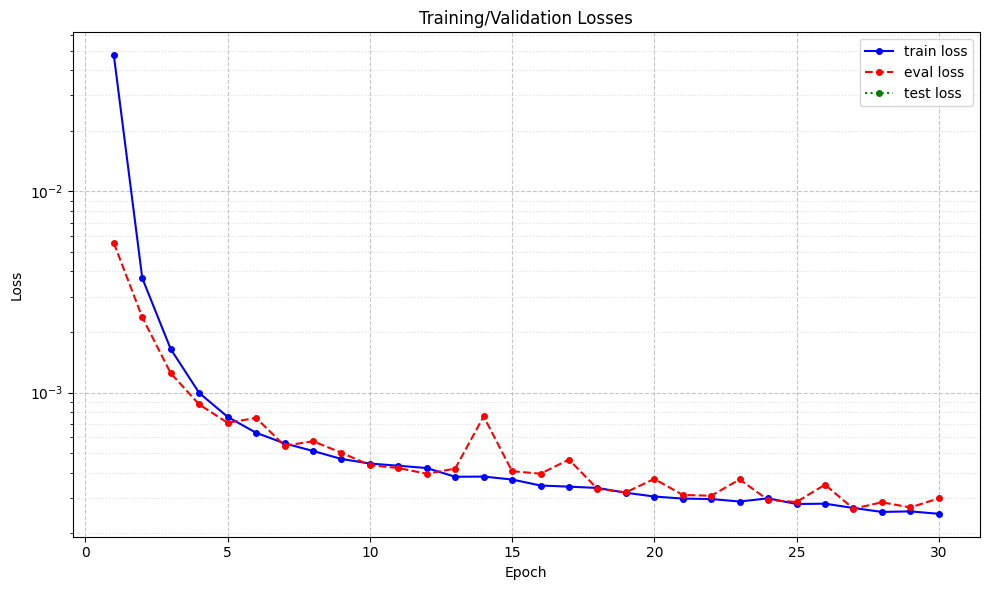

In [148]:
# Use it after training
plot_training_losses(trainer)

In [149]:
def load_and_preprocess_synthetic_test(dataset_root, normalizer, test_config):
    """Load and preprocess synthetic test data"""
    # Extract values from test_config
    unit = test_config['unit']
    test_set = test_config['test_set']
    anomaly_type = test_config['anomaly_type']
    
    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    print(f"\nLoading file: {anomaly_file}")
    
    test_data = pq.read_table(anomaly_file).to_pandas()
    
    # Filter for operating conditions
    operating_conditions_mask = (
        (test_data['dyn_only_on'] == False) & 
        (test_data['turbine_mode'] == True) & 
        (test_data['equilibrium_turbine_mode'] == True) & 
        (test_data['short_circuit_mode'] == False)
    )
    test_data = test_data[operating_conditions_mask]
    
    # Extract ground truth
    ground_truth = test_data['ground_truth']
    
    # Process control signals - Create feature sums
    # Create water opening sum
    test_data = create_scaled_sum_feature(test_data.copy(), ["water", "opening"], "water_opening_sum")
    
    # Create injector opening sum
    test_data = create_scaled_sum_feature(test_data.copy(), ["injector", "opening"], "injector_opening_sum")
    
    # Get control and sensor data
    control_cols = control_df.columns
    sensor_cols = SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns
    
    control_data = test_data[control_cols].copy()
    sensor_data = test_data[sensor_cols].copy()
    
    # Print ranges before normalization
    print("\nTest data before normalization:")
    print(f"Control data range: {control_data.min().min():.3f} to {control_data.max().max():.3f}")
    print(f"Sensor data range: {sensor_data.min().min():.3f} to {sensor_data.max().max():.3f}")
    
    # Normalize using the same scalers as training
    control_normalized, sensor_normalized = normalizer.transform(control_data, sensor_data)
    
    # Print ranges after normalization
    print("\nTest data after normalization:")
    print(f"Control data range: {control_normalized.min().min():.3f} to {control_normalized.max().max():.3f}")
    print(f"Sensor data range: {sensor_normalized.min().min():.3f} to {sensor_normalized.max().max():.3f}")
    
    return control_normalized, sensor_normalized, ground_truth

In [ ]:
def plot_predictions_with_ground_truth(df_test, ground_truth, sensor_idx=0, sensor_name=None):
    """
    Plot predictions vs true values with ground truth anomalies
    """
    sensor_data = df_test[df_test['sensor'] == sensor_idx].copy()  # Make a copy
    
    # Set the same index as ground_truth for sensor_data
    sensor_data.index = ground_truth.index[:len(sensor_data)]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), height_ratios=[3, 1], sharex=True)
    
    # Print debug info
    print(f"\nPlotting ranges:")
    print(f"Sensor data index range: {sensor_data.index[0]} to {sensor_data.index[-1]}")
    print(f"Ground truth index range: {ground_truth.index[0]} to {ground_truth.index[-1]}")
    
    # Upper subplot - Temperature predictions
    ax1.plot(sensor_data.index, sensor_data['true'], label='True', color='blue', alpha=0.6)
    ax1.plot(sensor_data.index, sensor_data['pred'], label='Predicted', color='red', alpha=0.6)
    
    # Plot prediction error
    error = np.abs(sensor_data['true'] - sensor_data['pred'])
    ax1.fill_between(
        sensor_data.index,
        sensor_data['true'] - error,
        sensor_data['true'] + error,
        color='gray',
        alpha=0.2,
        label='Prediction Error'
    )
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean(error**2))
    
    # Get sensor name if not provided
    if sensor_name is None:
        sensor_name = SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns[sensor_idx]
    
    # Set title and labels for upper subplot
    title = f'Sensor: {sensor_name}\nRMSE: {rmse:.4f}'
    ax1.set_title(title)
    ax1.set_ylabel('Temperature')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Lower subplot - Ground truth anomalies
    anomaly_mask = ground_truth == 1
    ax2.fill_between(
        ground_truth.index,
        0, 1,
        where=anomaly_mask,
        color='yellow',
        alpha=0.3,
        label='Anomaly Period',
        step='post'
    )

    
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_ylabel('Anomaly')
    ax2.set_xlabel('Time')
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Format x-axis dates
    plt.gcf().autofmt_xdate()
    from matplotlib.dates import DateFormatter
    ax2.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    
    plt.tight_layout()
    plt.show()

# Function to plot all sensors
def plot_all_sensors(df_test, ground_truth):
    """Plot predictions for all sensors"""
    n_sensors = len(SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns)
    print(f"\nPlotting all {n_sensors} sensors...")
    
    for sensor_idx in range(n_sensors):
        sensor_name = SENSOR_GROUPS[SELECTED_SENSOR_GROUP].columns[sensor_idx]
        print(f"\nPlotting sensor {sensor_idx}: {sensor_name}")
        plot_predictions_with_ground_truth(df_test, ground_truth, sensor_idx=sensor_idx, sensor_name=sensor_name)

In [ ]:
# Also, let's verify the ground truth data before plotting
def print_ground_truth_info(ground_truth):
    """Print information about the ground truth anomalies"""
    anomaly_periods = ground_truth[ground_truth == 1]
    print("\nGround Truth Information:")
    print(f"Total timepoints: {len(ground_truth)}")
    print(f"Number of anomaly points: {len(anomaly_periods)}")
    print("\nAnomaly periods:")
    
    # Find continuous periods of anomalies
    anomaly_starts = []
    anomaly_ends = []
    in_anomaly = False
    
    for i in range(len(ground_truth)):
        if ground_truth.iloc[i] == 1 and not in_anomaly:
            anomaly_starts.append(ground_truth.index[i])
            in_anomaly = True
        elif ground_truth.iloc[i] == 0 and in_anomaly:
            anomaly_ends.append(ground_truth.index[i-1])
            in_anomaly = False
    
    if in_anomaly:  # If last period was an anomaly
        anomaly_ends.append(ground_truth.index[-1])
    
    for start, end in zip(anomaly_starts, anomaly_ends):
        print(f"From: {start.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"To:   {end.strftime('%Y-%m-%d %H:%M:%S')}")
        print("---")

# Also, let's modify the evaluation function to align the ground truth with predictions
def evaluate_on_synthetic_test(trainer, dataset_root, unit="VG5", test_set="01", anomaly_type="a"):
    """
    Evaluate model on synthetic test set
    """
    # Load and preprocess synthetic test data
    control_test, sensors_test, ground_truth = load_and_preprocess_synthetic_test(dataset_root)
    
    # Create test dataset
    test_dataset = SlidingWindowDataset(
        control_test, 
        sensors_test,
        window=DEFAULT_PARAMS['window']
    )
    
    # Create test loader
    test_loader = DataLoader(
        test_dataset, 
        batch_size=DEFAULT_PARAMS['batch_size'],
        shuffle=False
    )
    
    # Evaluate model
    print("Evaluating on synthetic test data...")
    df_test, df_metrics = trainer.eval_prediction(test_loader)
    
    # Print value ranges
    print("\nPrediction ranges:")
    print(f"True values range: {df_test['true'].min():.3f} to {df_test['true'].max():.3f}")
    print(f"Predicted values range: {df_test['pred'].min():.3f} to {df_test['pred'].max():.3f}")
    
    # Plot results for each sensor with ground truth overlay
    for sensor_idx in range(sensors_test.shape[1]):
        plot_predictions_with_ground_truth(
            df_test, 
            ground_truth, 
            sensor_idx=sensor_idx,
            sensor_name=sensors_test.columns[sensor_idx]
        )
    
    return df_test, df_metrics, ground_truth



Setting up training for stator_temperature
Input channels: 37
Output channels: 30

Before normalization:
Control data range: 0.000 to 1.000
Sensor data range: 0.000 to 1.000

After normalization:
Control data range: 0.000 to 1.000
Sensor data range: 0.000 to 1.000

Dataset sizes:
Train: 36144
Validation: 9035
Test configuration:
{'unit': 'VG5', 'test_set': '01', 'anomaly_type': 'a'}

Loading file: dataset\synthetic_anomalies\VG5_anomaly_01_type_a.parquet

Test data before normalization:
Control data range: -1.525 to 503.067
Sensor data range: 33.200 to 83.251

Test data after normalization:
Control data range: -1.525 to 503.067
Sensor data range: 33.200 to 83.251
Evaluating predictions...


100%|██████████| 177/177 [00:02<00:00, 78.78it/s]


Predictions shape: (45179, 30)
True values shape: (45179, 30)

DataFrame shape: (1355370, 5)
DataFrame columns: ['pred', 'true', 'error', 'abs_error', 'sensor']

Metrics:
     sensor       rmse
0         0   1.765541
1         1   1.365585
2         2   0.942785
3         3   1.827717
4         4   5.140297
5         5   4.935313
6         6   3.966519
7         7   2.420552
8         8   1.552295
9         9   0.814954
10       10   2.925427
11       11  10.480008
12       12   6.492171
13       13   3.379022
14       14   3.330251
15       15   1.079869
16       16   4.802539
17       17   1.582399
18       18   1.413337
19       19   7.778883
20       20  26.197775
21       21   4.322832
22       22   7.304574
23       23  31.111546
24       24   9.507014
25       25   5.183542
26       26  25.982903
27       27   5.767988
28       28   9.489870
29       29  21.005350
30  overall  10.708500

Plotting all 30 sensors...

Plotting sensor 0: stat_coil_ph01_01_tmp

Plotting ranges:
Senso

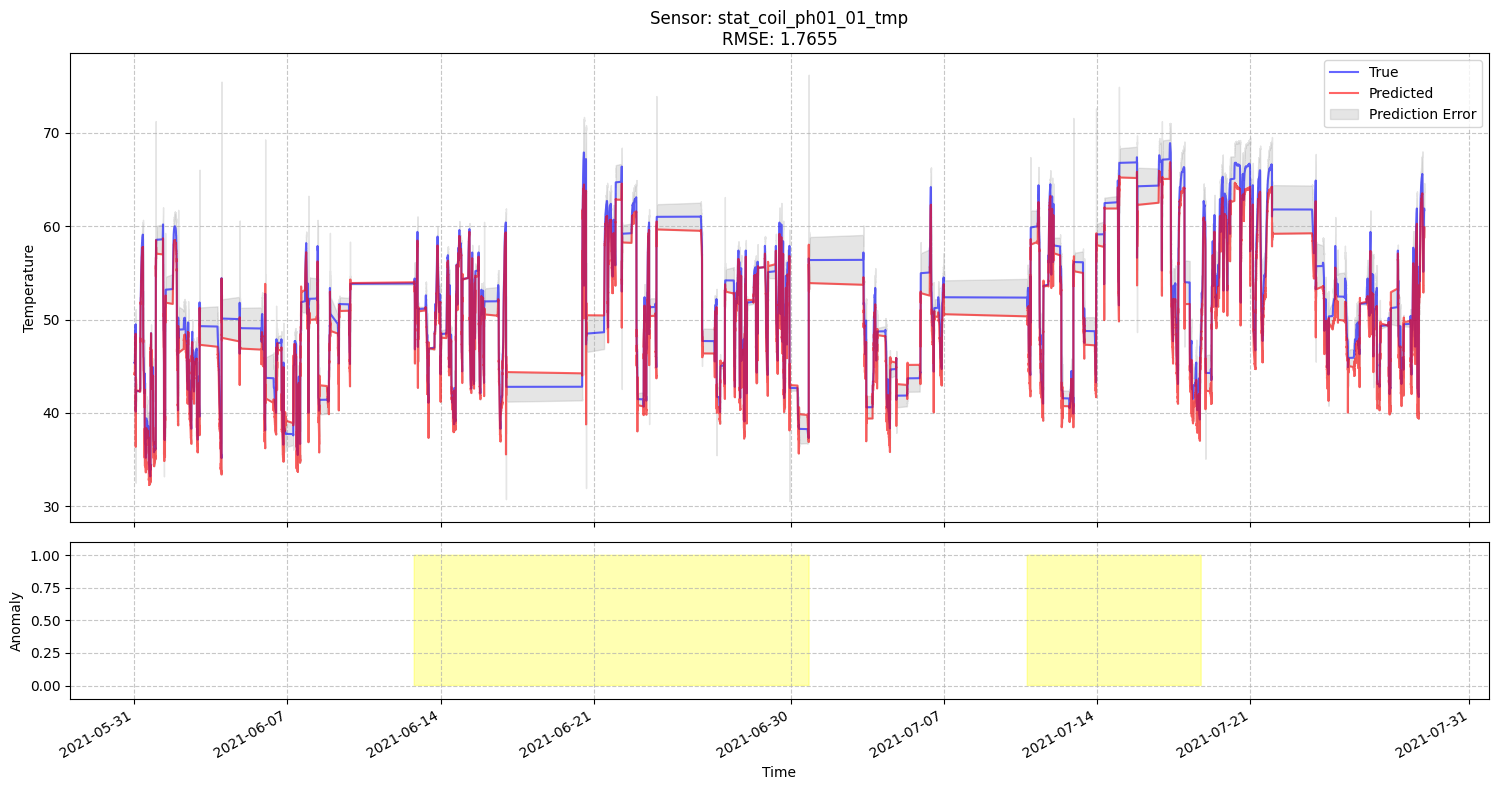


Plotting sensor 1: stat_coil_ph01_02_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph01_02_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


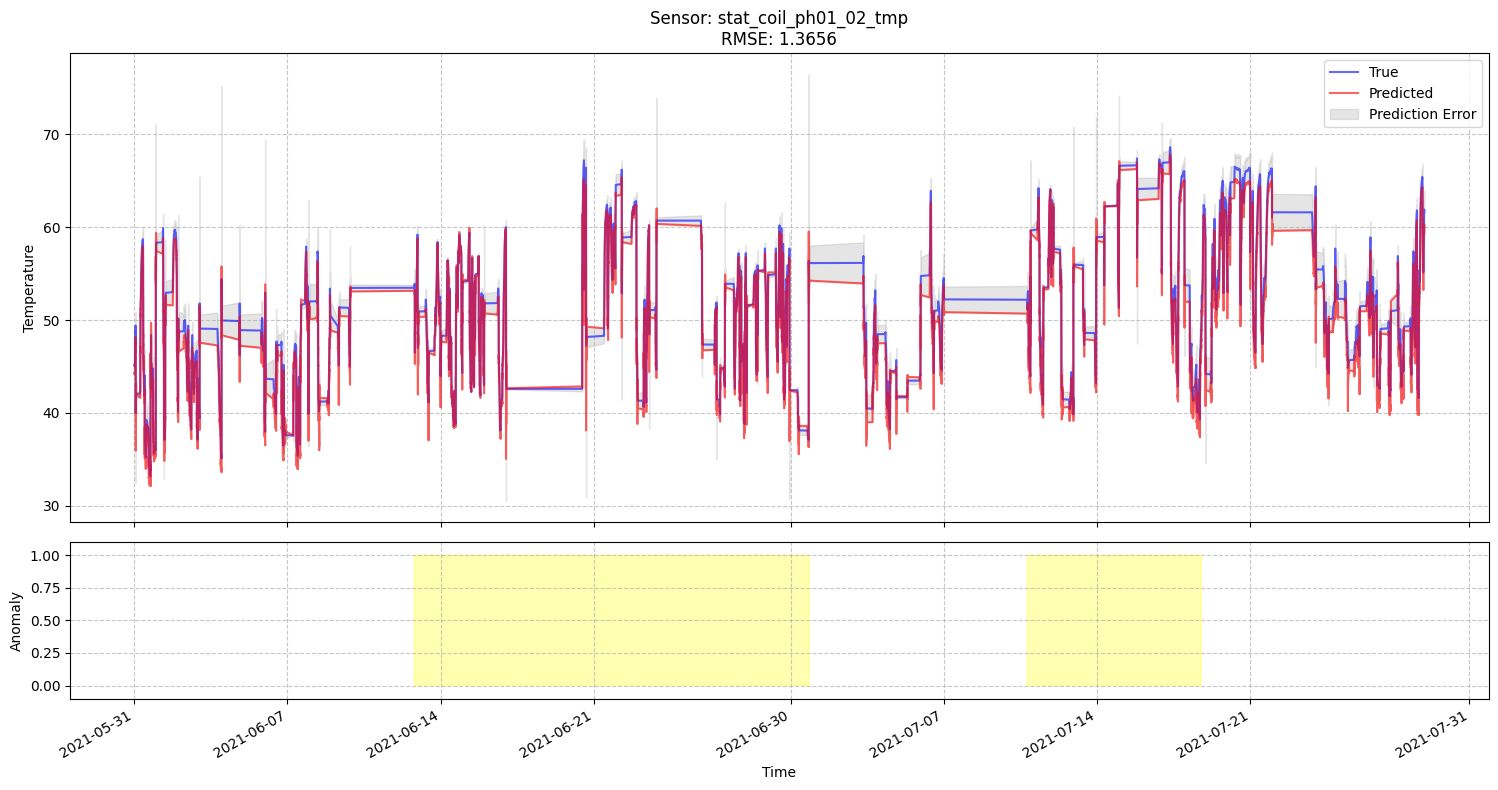


Plotting sensor 2: stat_coil_ph01_03_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph01_03_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


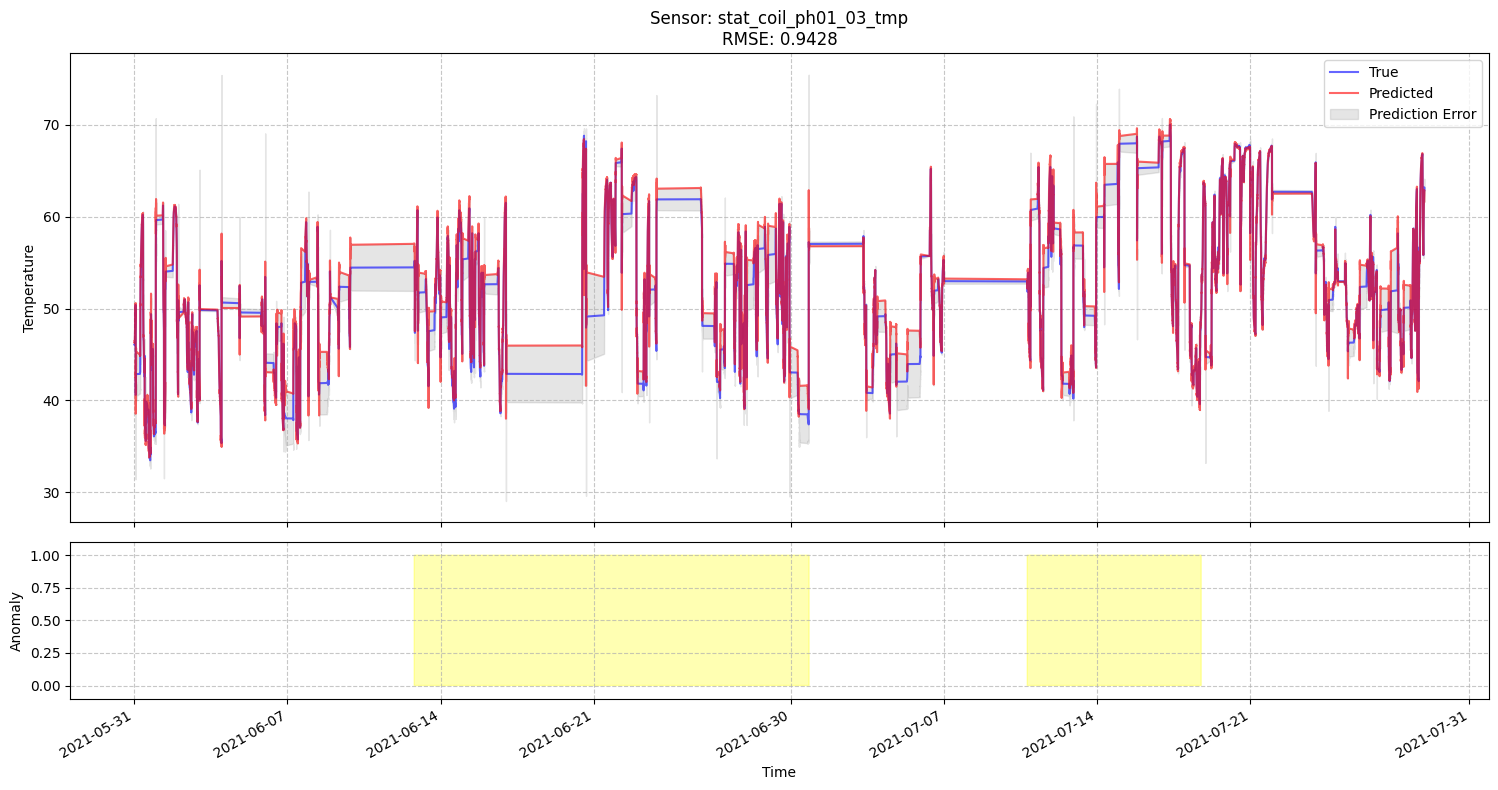


Plotting sensor 3: stat_coil_ph01_04_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph01_04_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


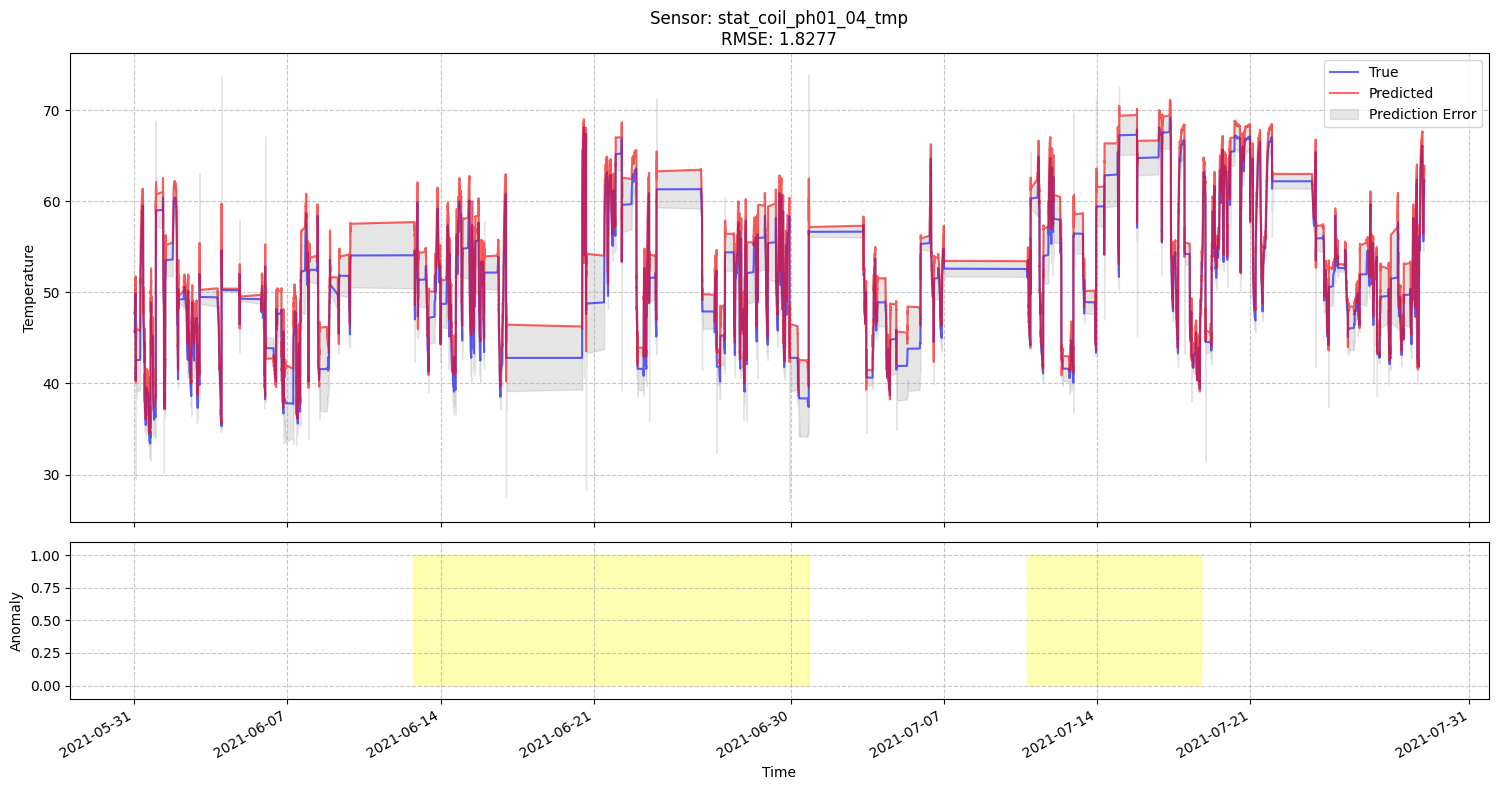


Plotting sensor 4: stat_coil_ph01_05_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph01_05_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


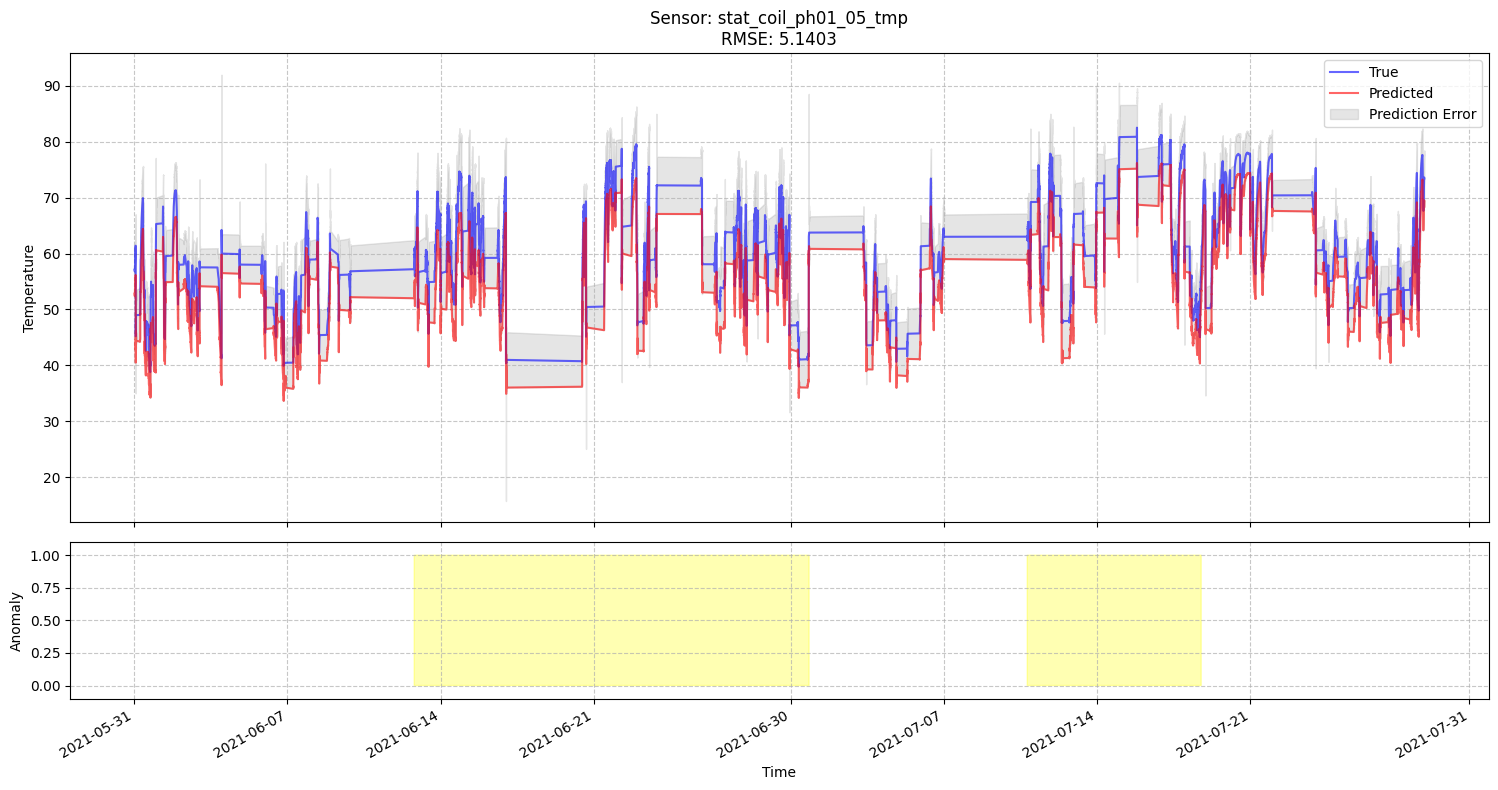


Plotting sensor 5: stat_coil_ph01_06_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph01_06_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


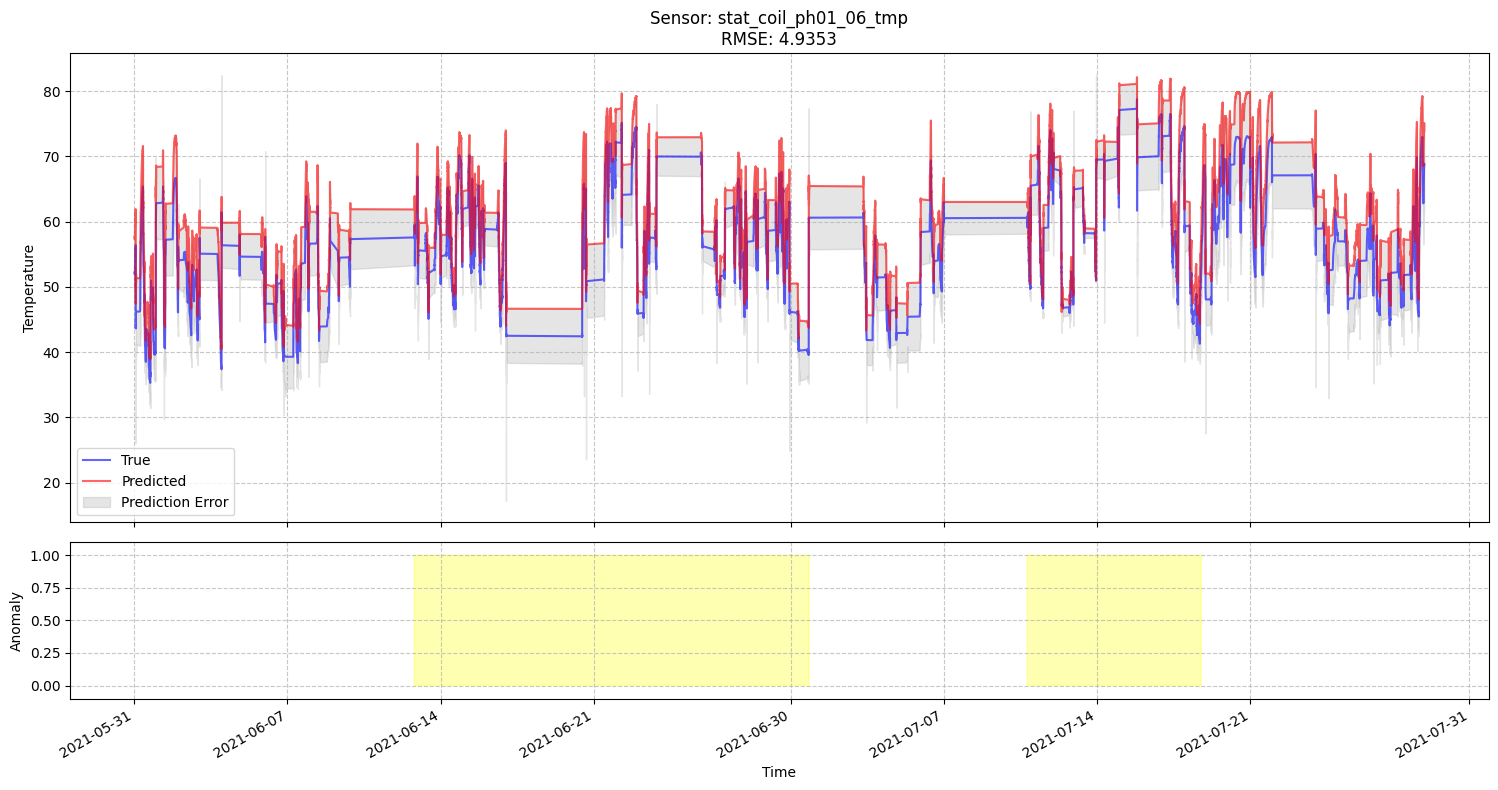


Plotting sensor 6: stat_coil_ph02_01_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_01_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


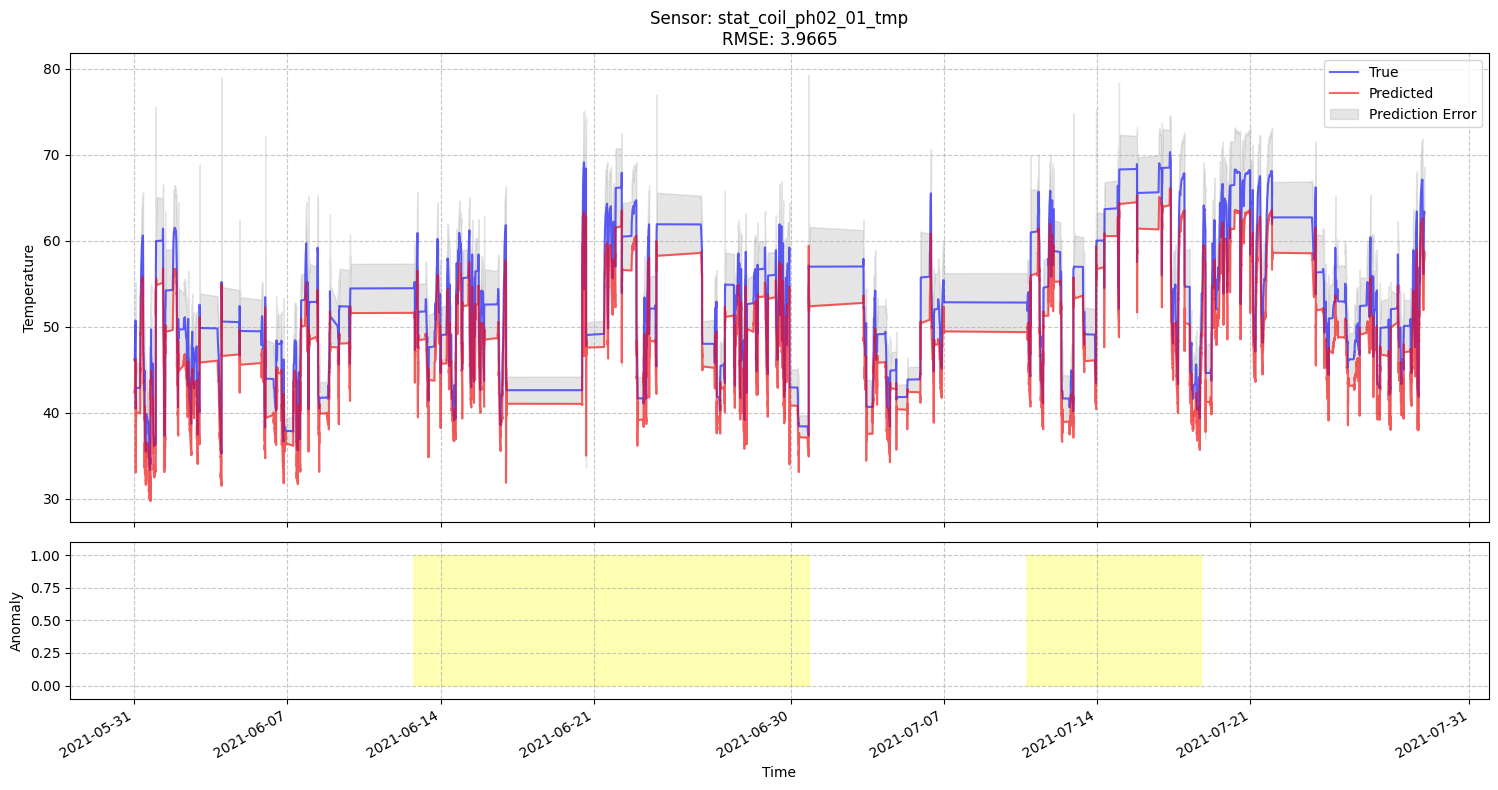


Plotting sensor 7: stat_coil_ph02_02_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_02_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


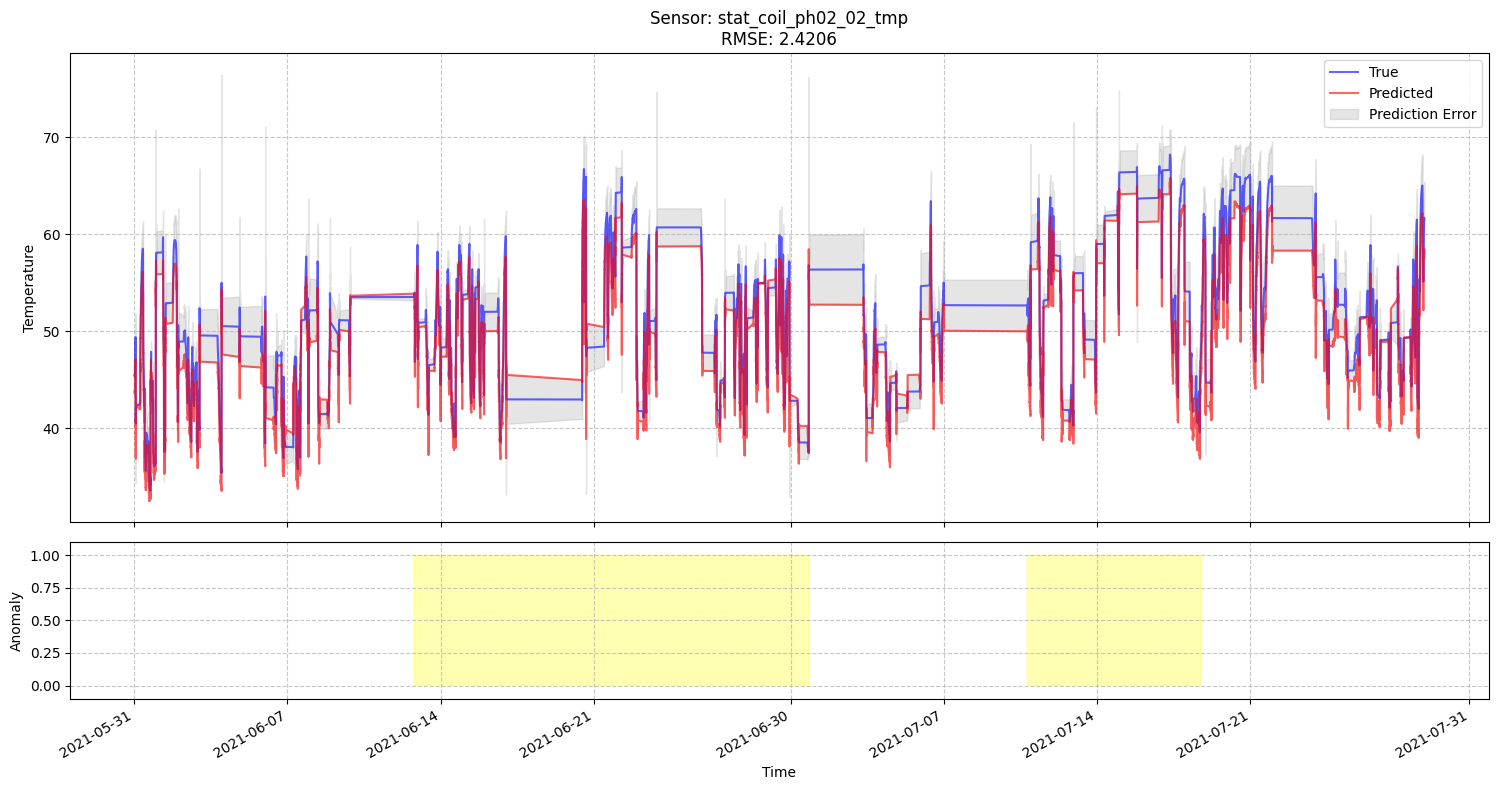


Plotting sensor 8: stat_coil_ph02_03_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_03_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


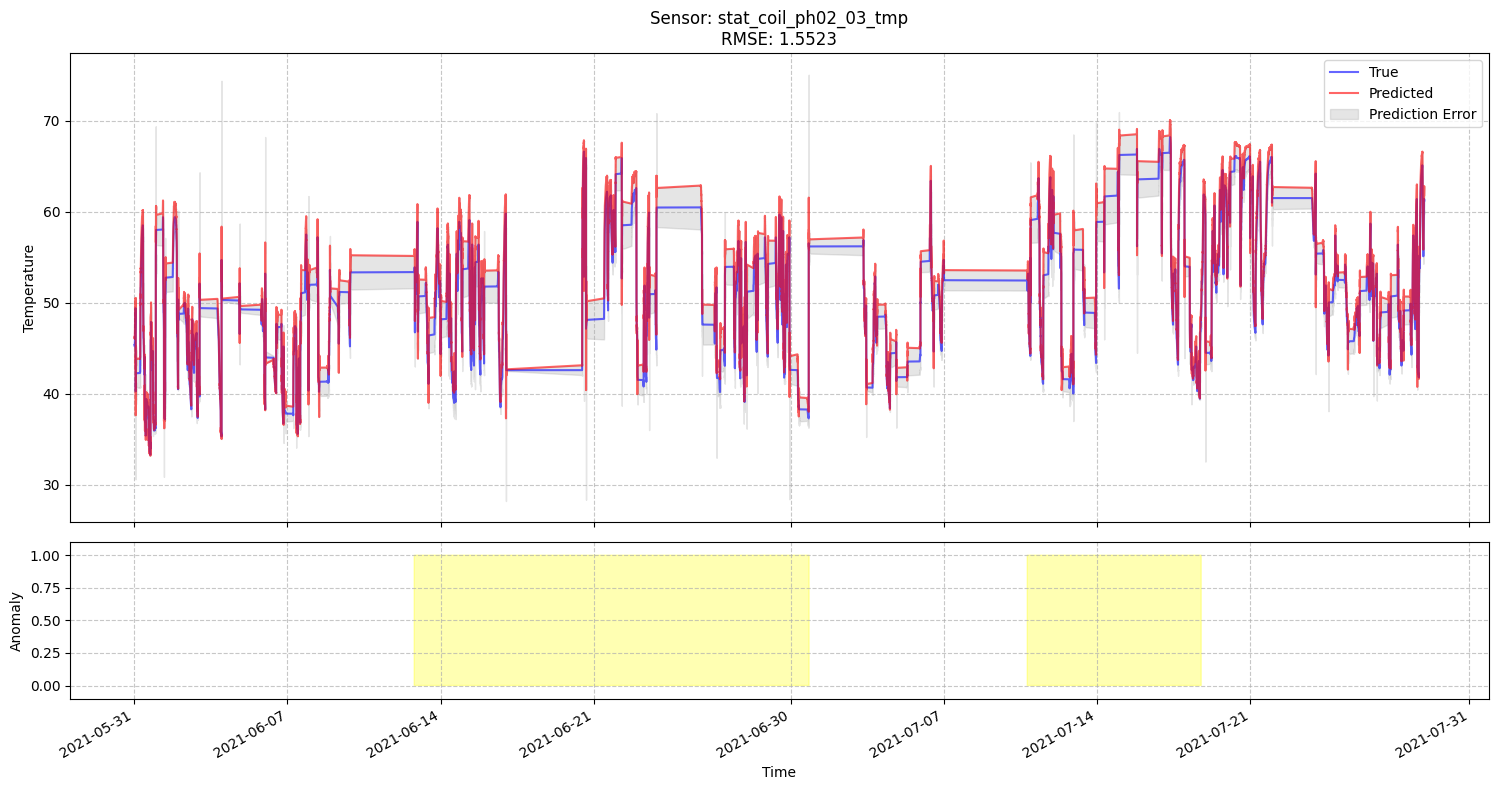


Plotting sensor 9: stat_coil_ph02_04_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_04_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


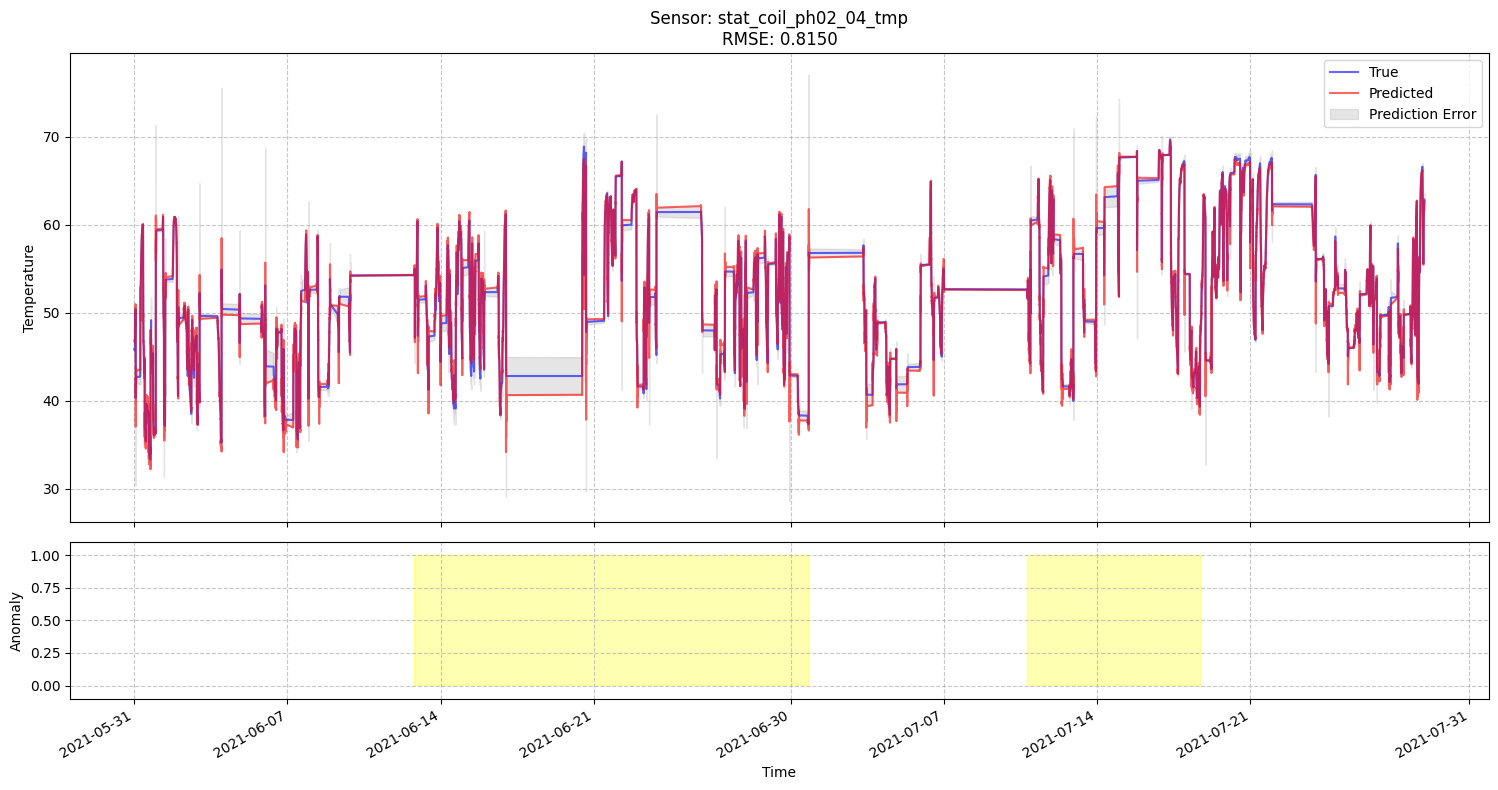


Plotting sensor 10: stat_coil_ph02_05_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_05_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


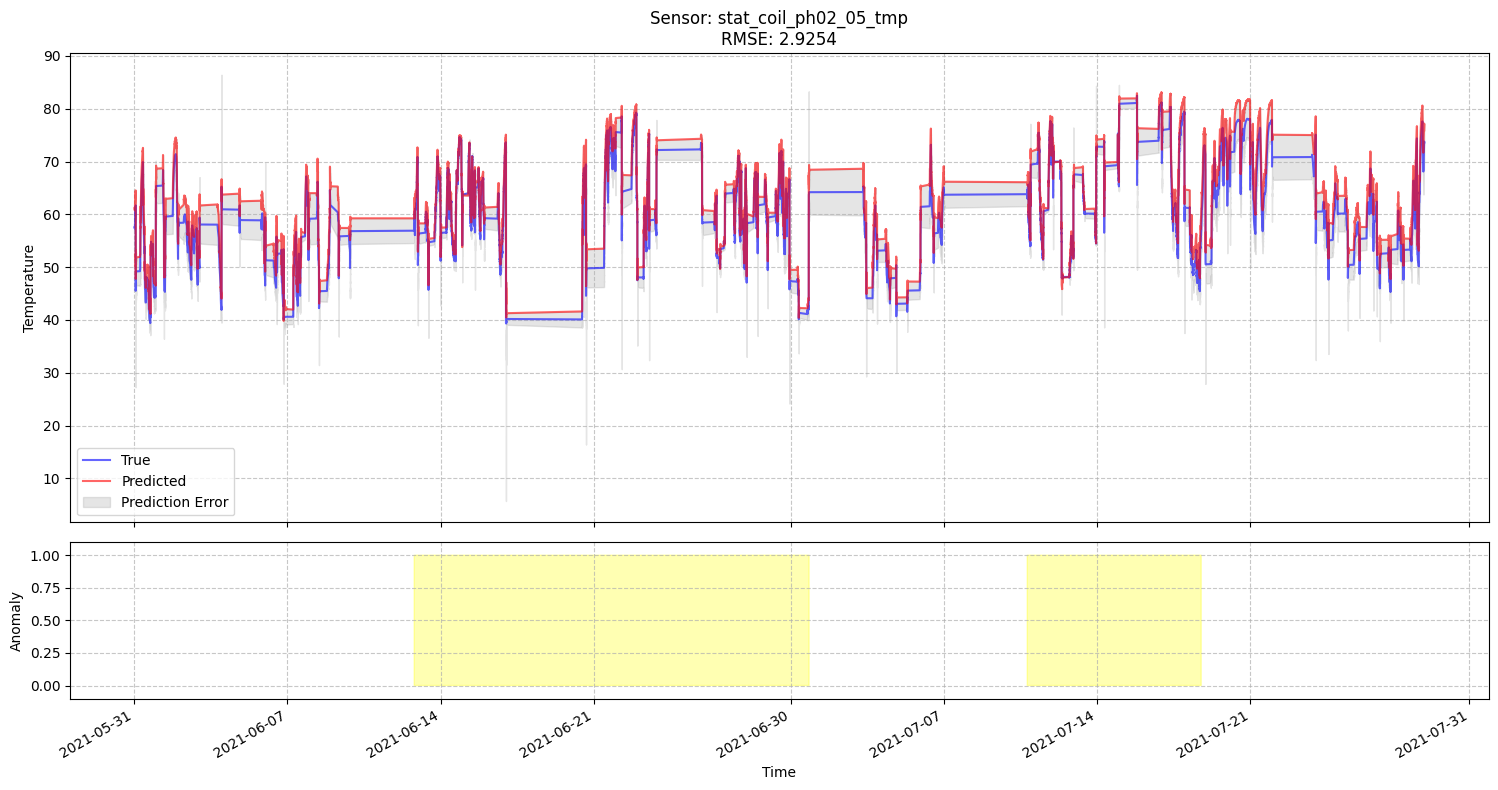


Plotting sensor 11: stat_coil_ph02_06_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph02_06_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


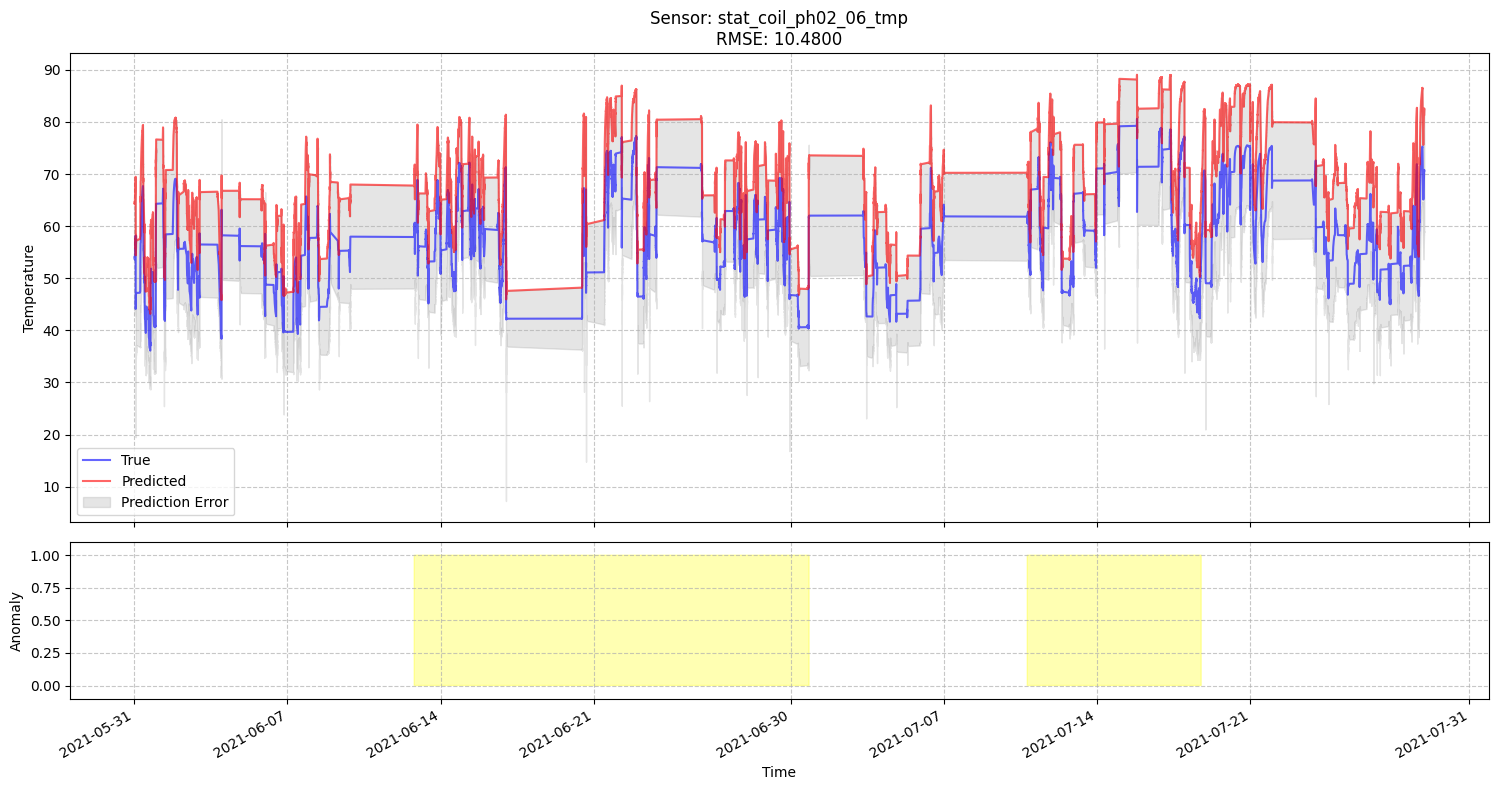


Plotting sensor 12: stat_coil_ph03_01_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_01_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


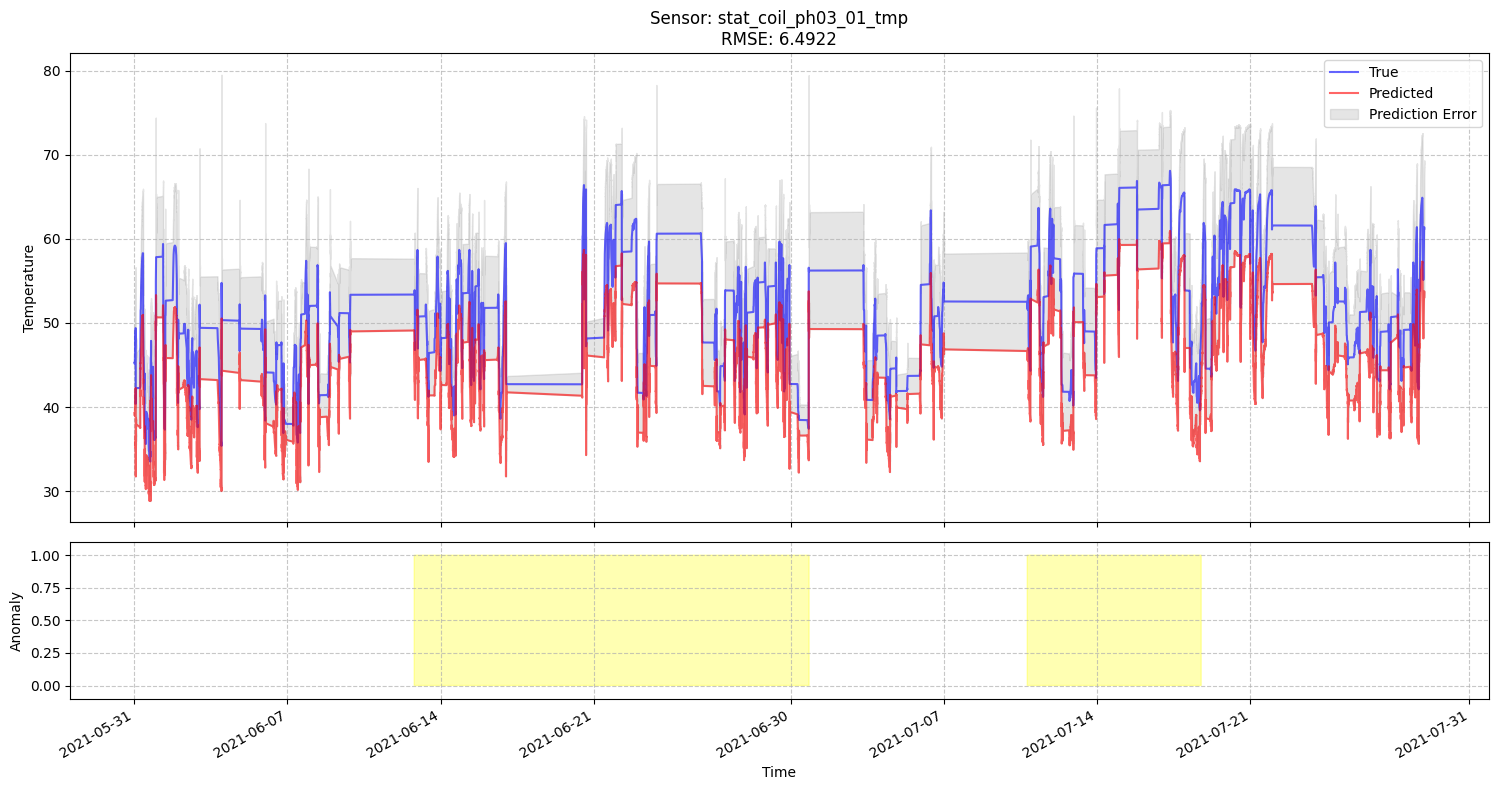


Plotting sensor 13: stat_coil_ph03_02_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_02_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


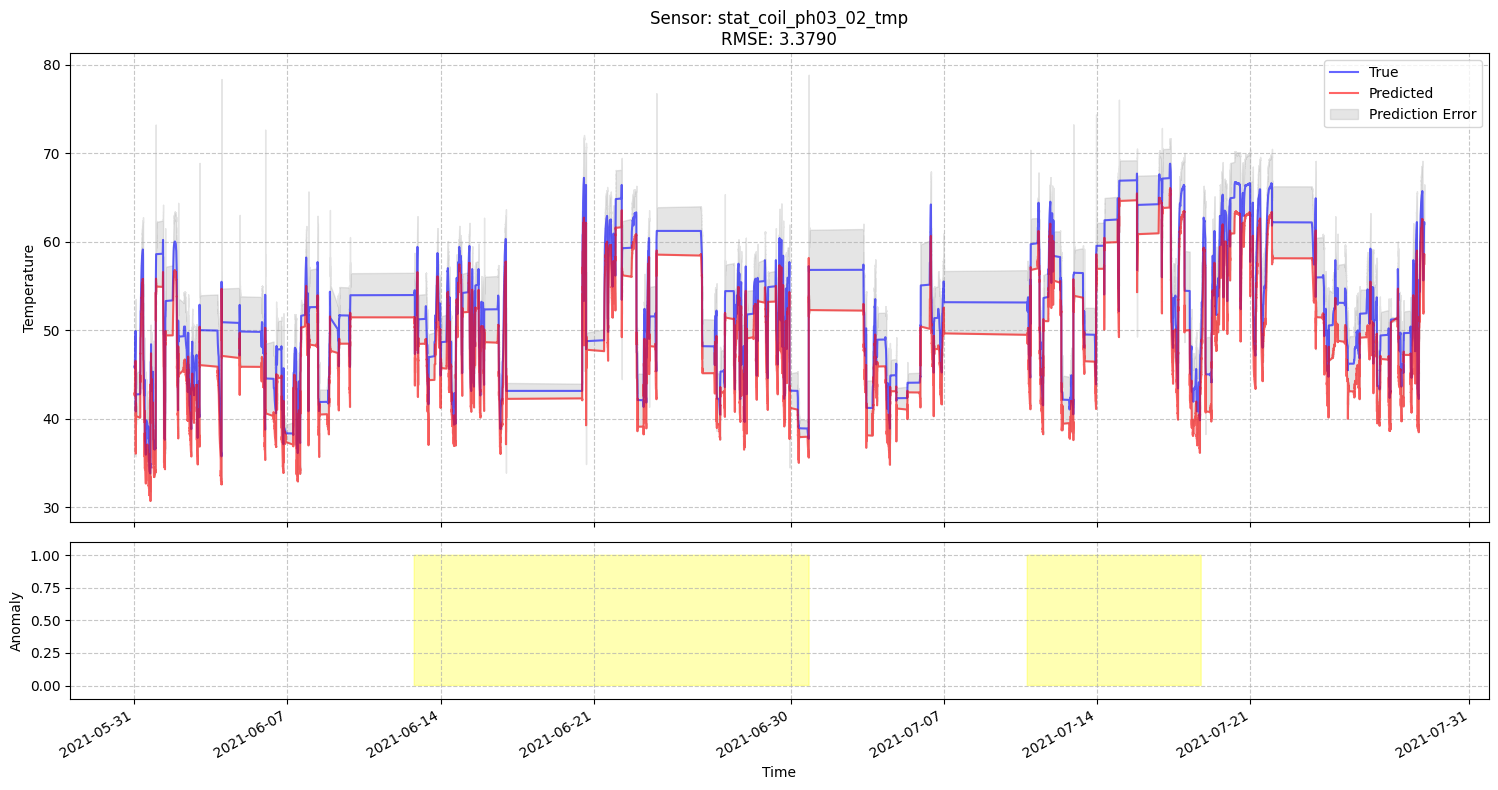


Plotting sensor 14: stat_coil_ph03_03_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_03_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


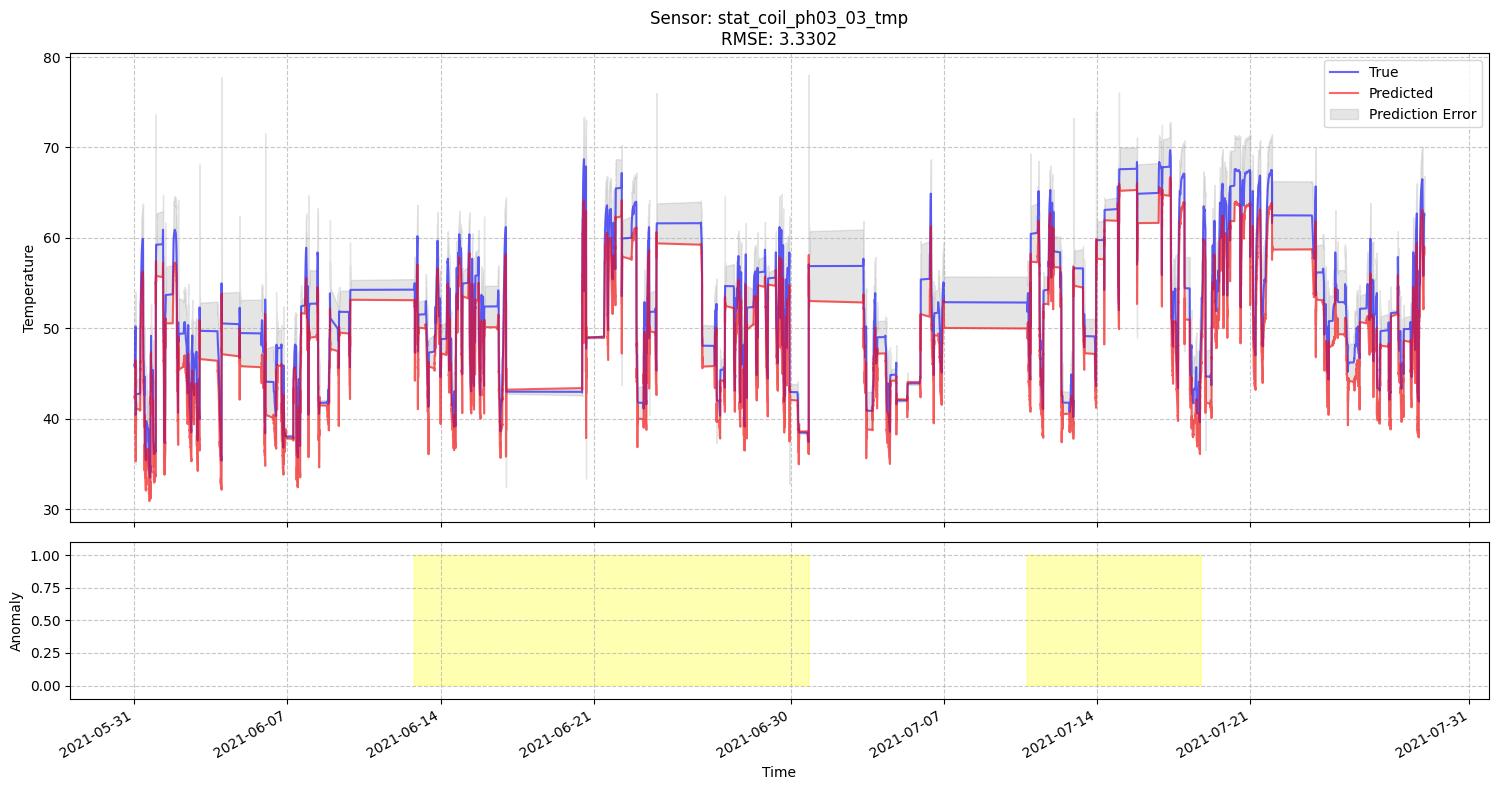


Plotting sensor 15: stat_coil_ph03_04_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_04_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


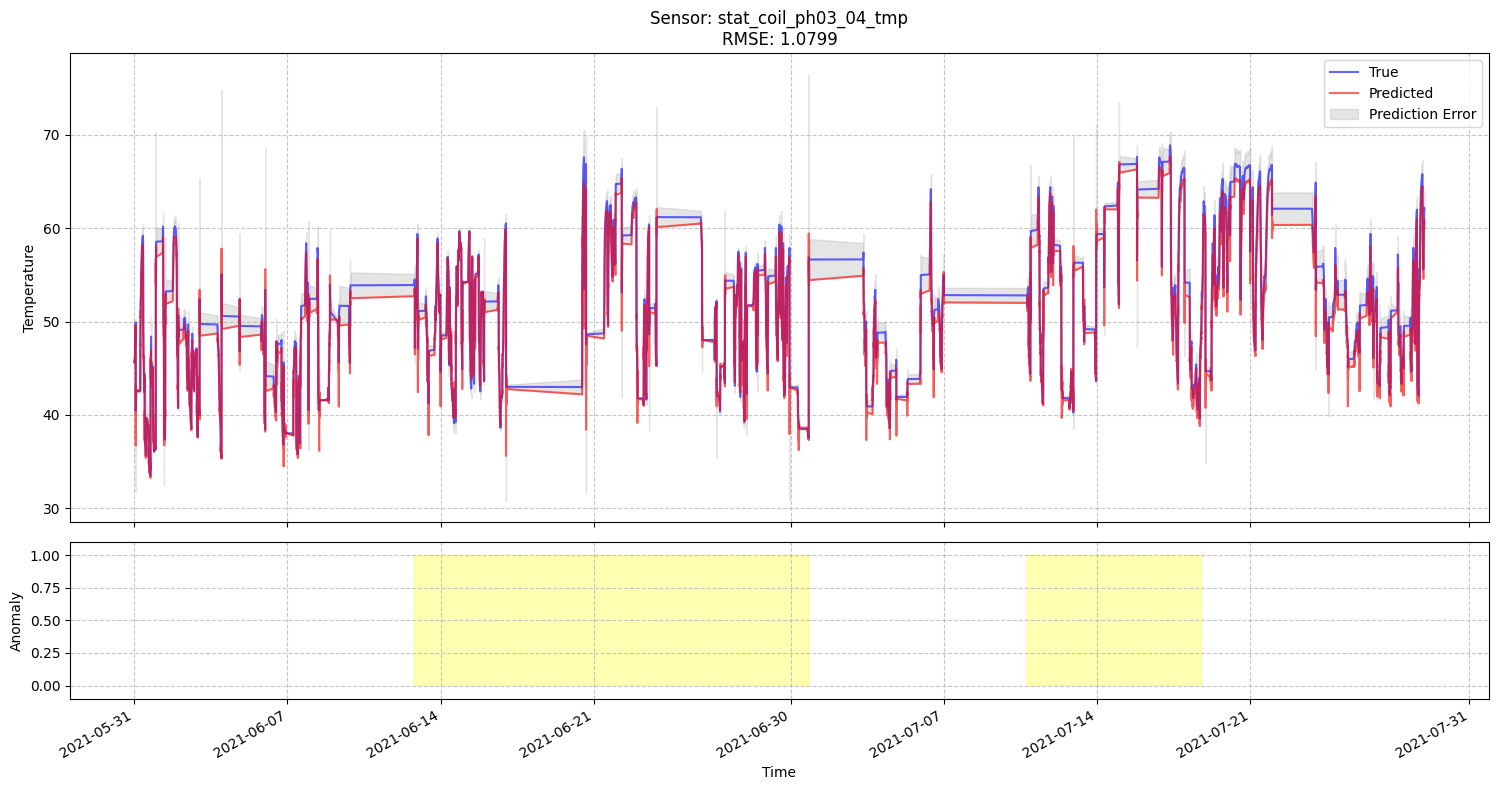


Plotting sensor 16: stat_coil_ph03_05_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_05_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


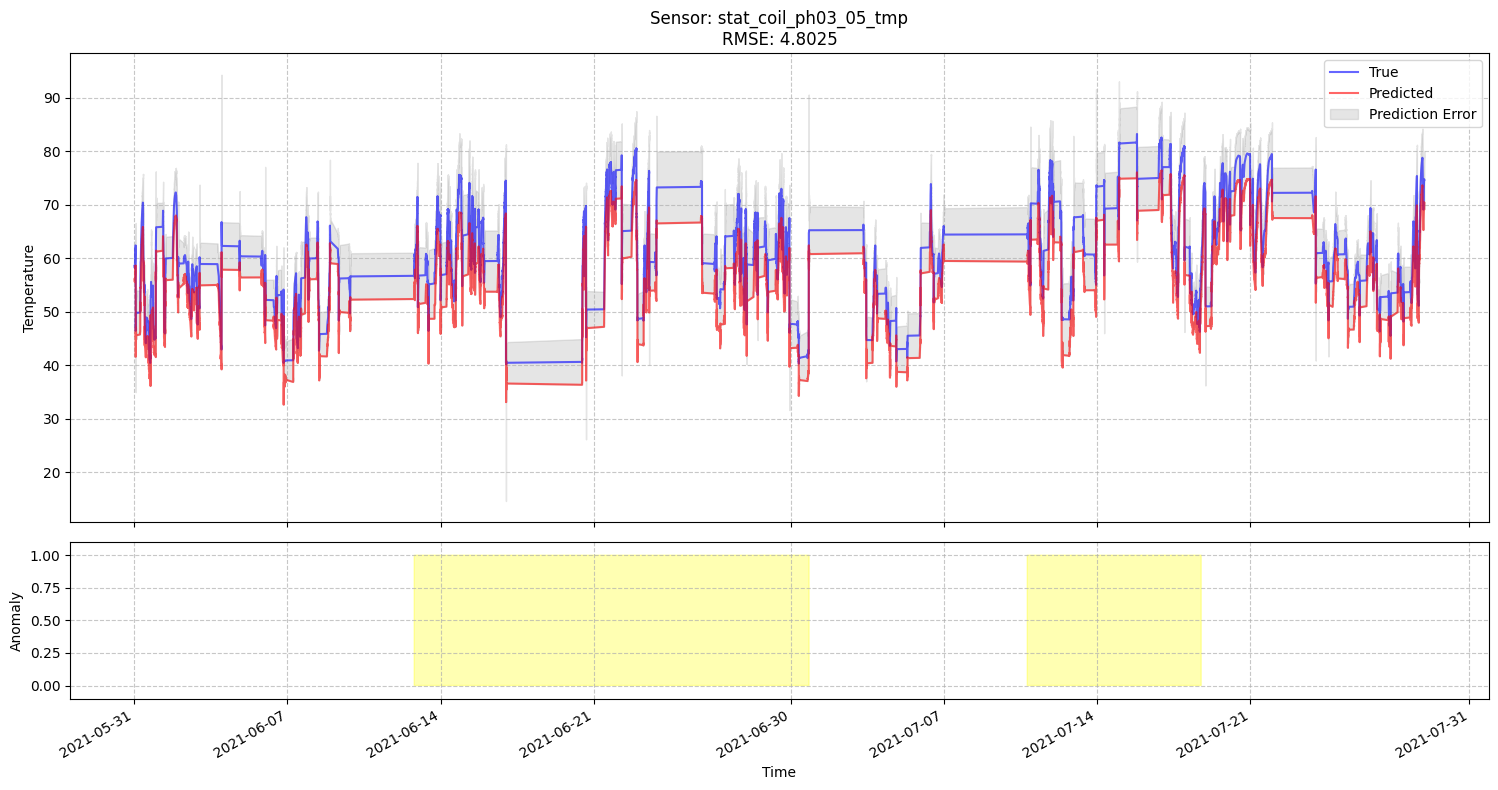


Plotting sensor 17: stat_coil_ph03_06_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_coil_ph03_06_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


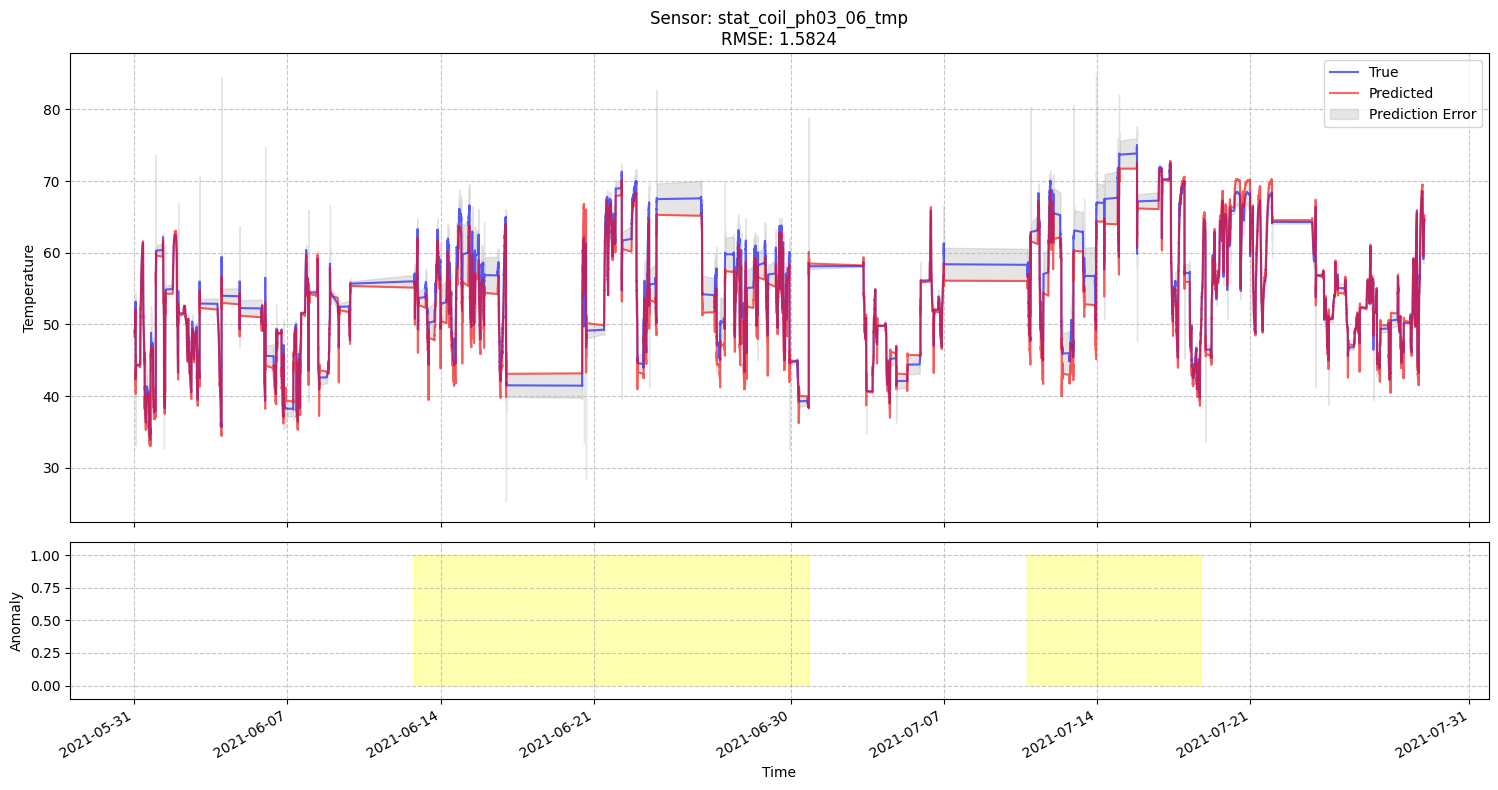


Plotting sensor 18: stat_magn_01_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_01_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


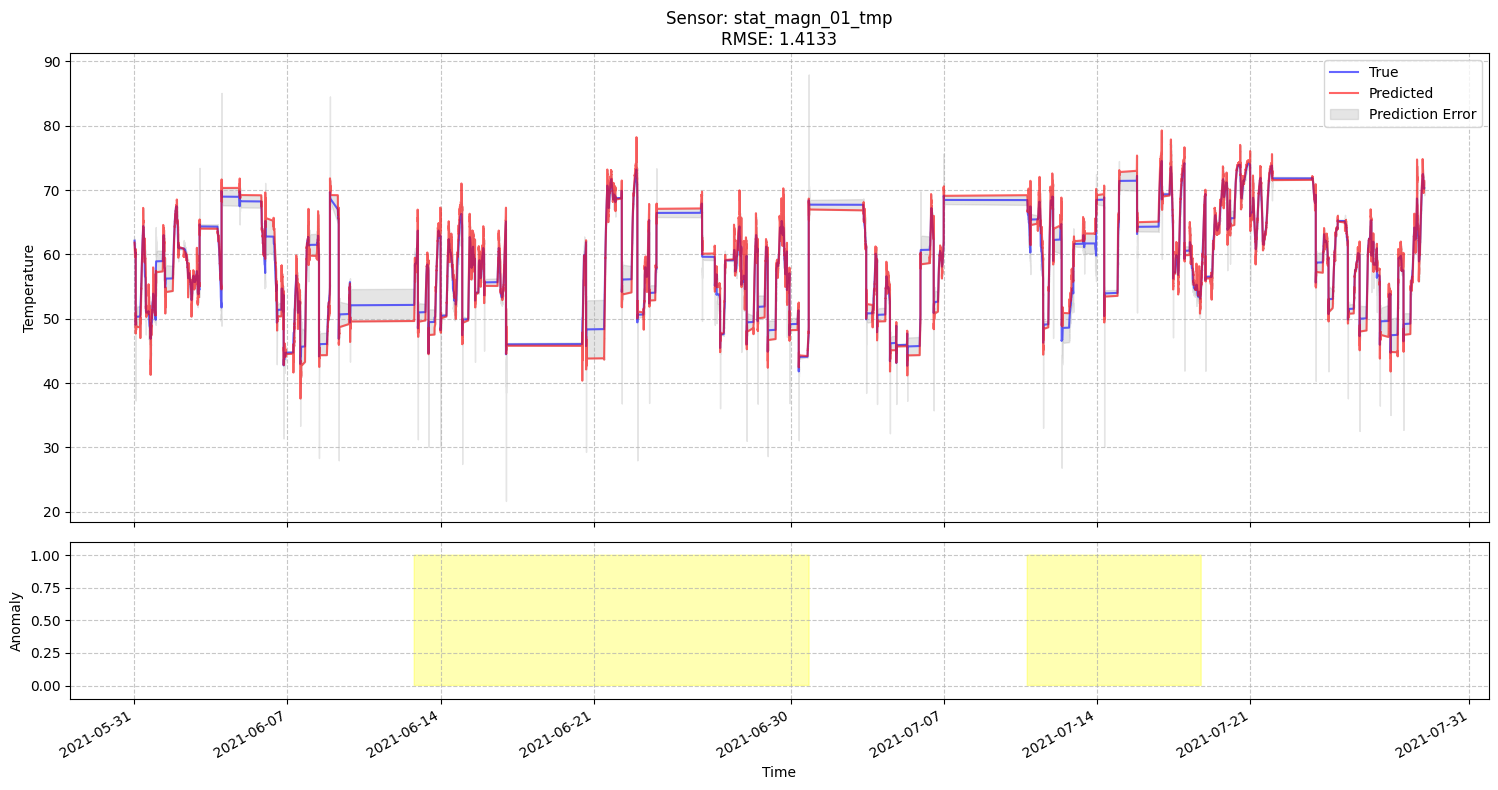


Plotting sensor 19: stat_magn_02_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_02_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


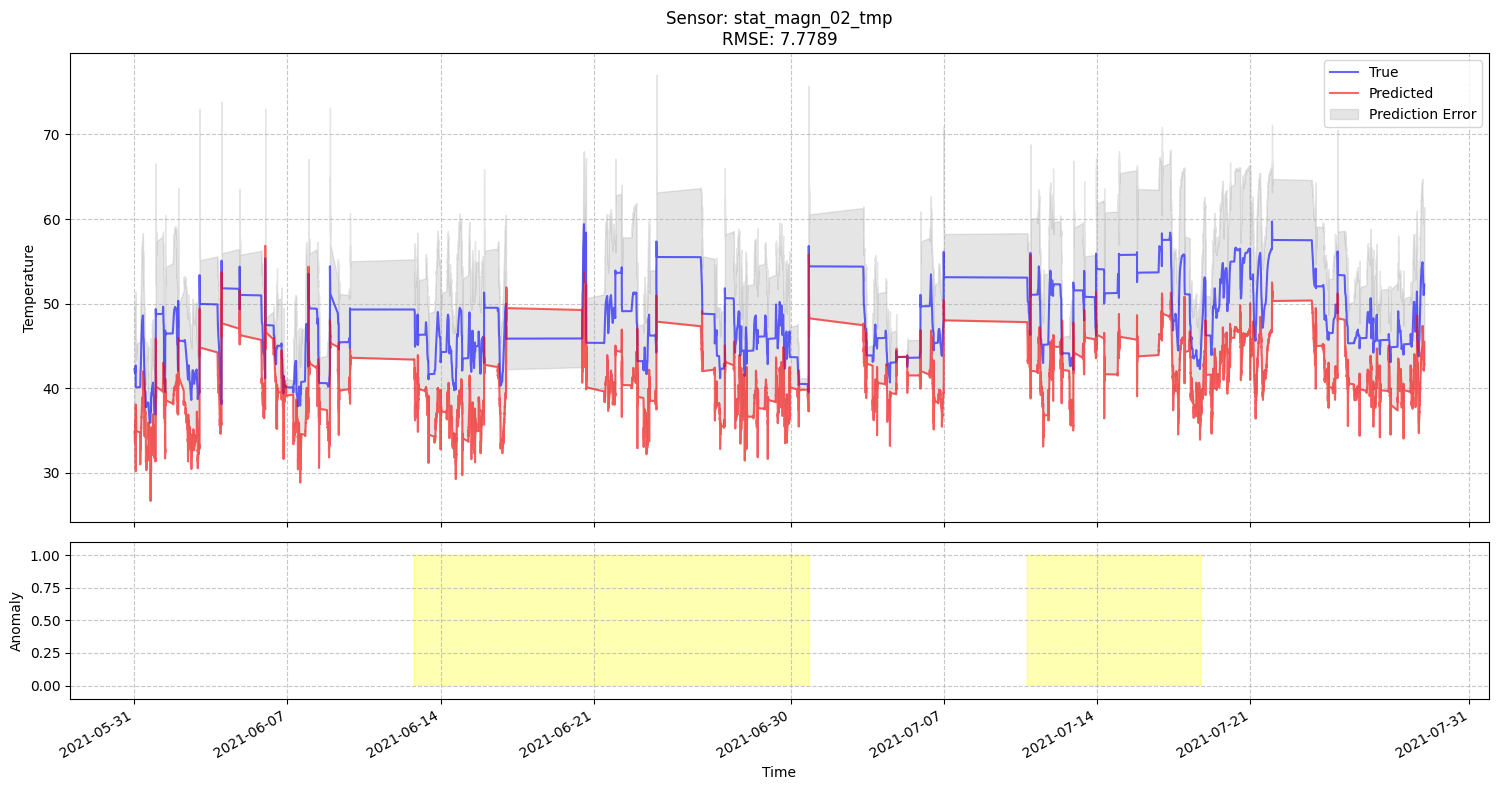


Plotting sensor 20: stat_magn_03_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_03_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


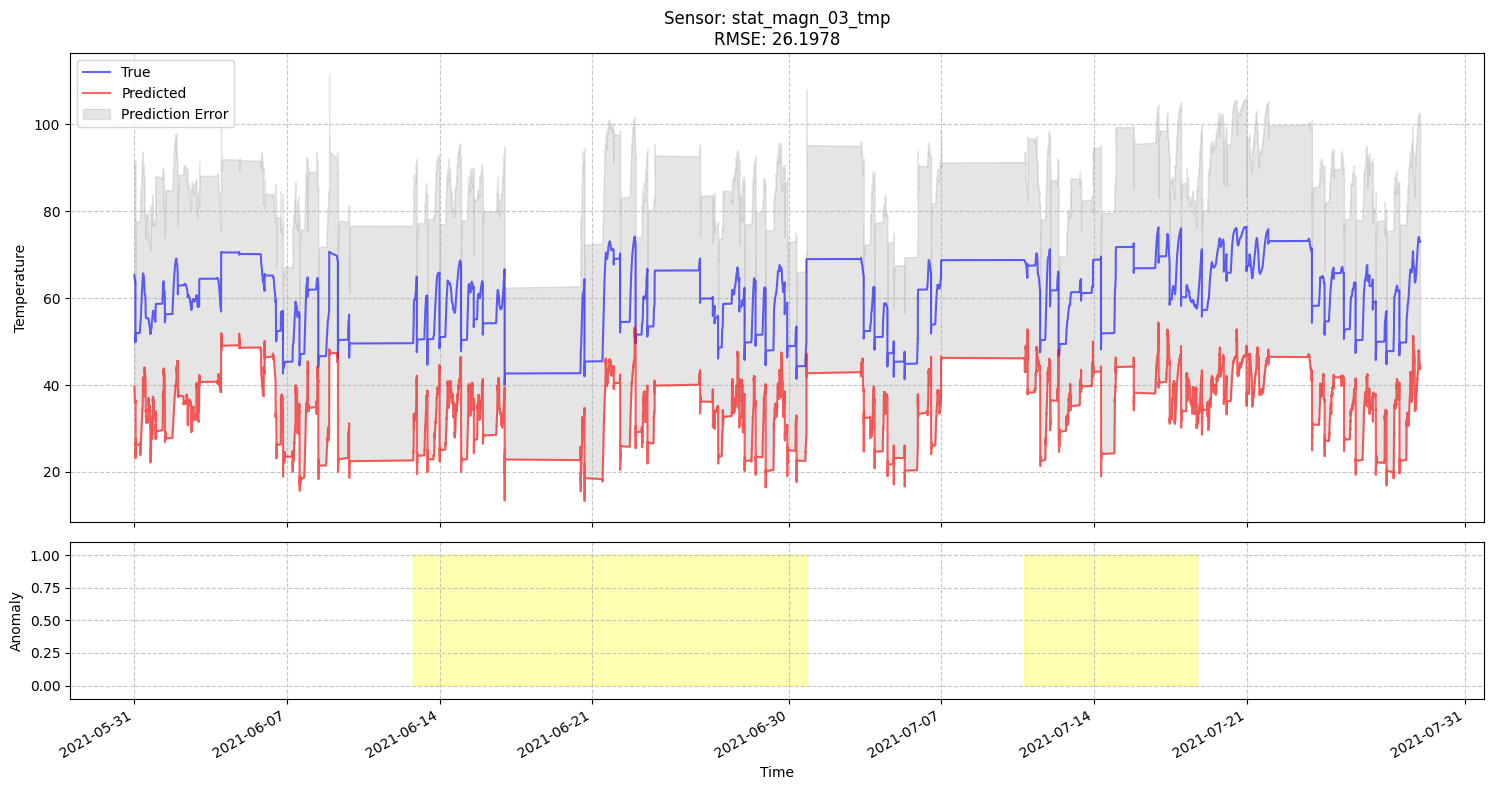


Plotting sensor 21: stat_magn_04_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_04_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


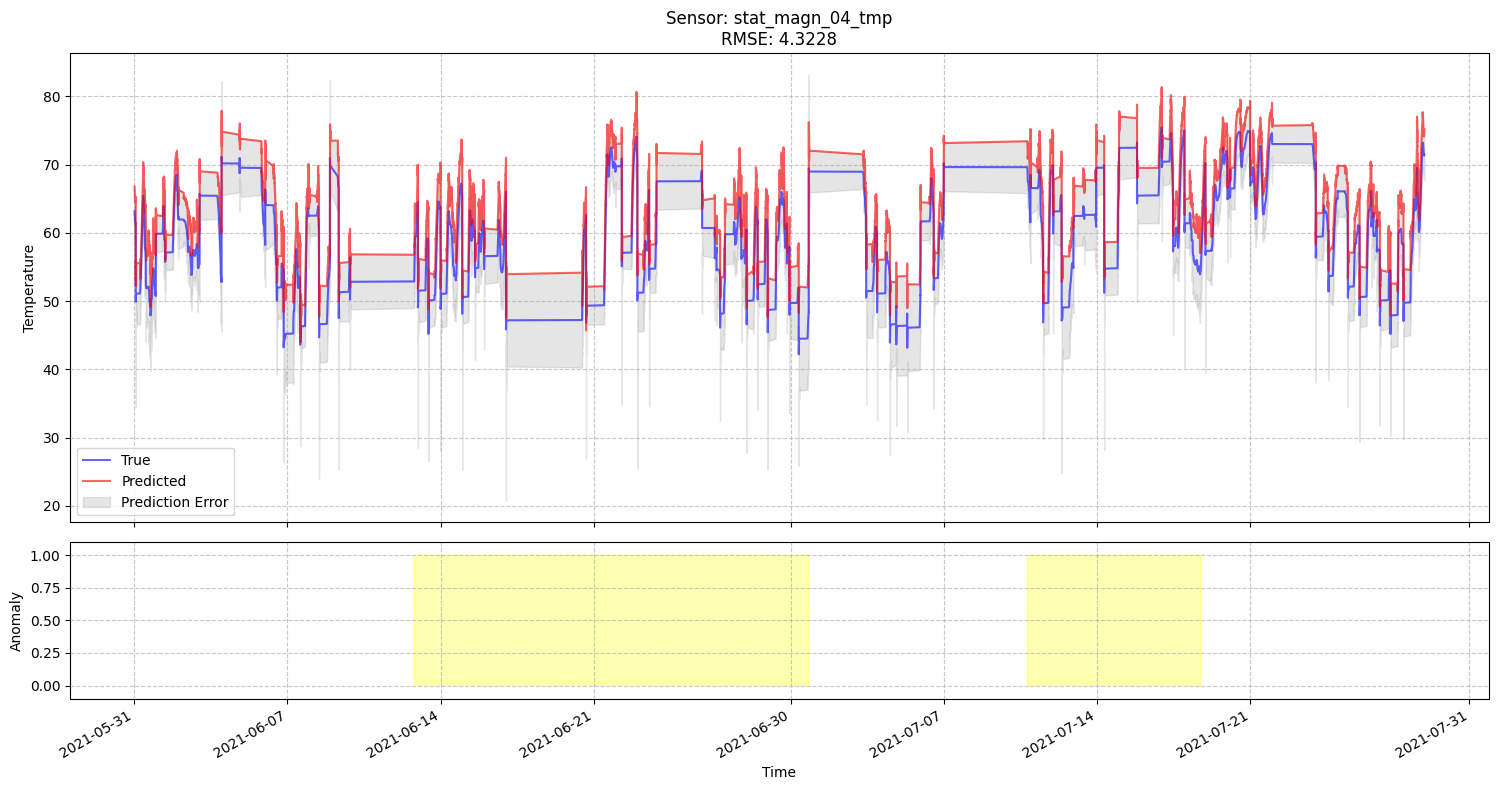


Plotting sensor 22: stat_magn_05_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_05_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


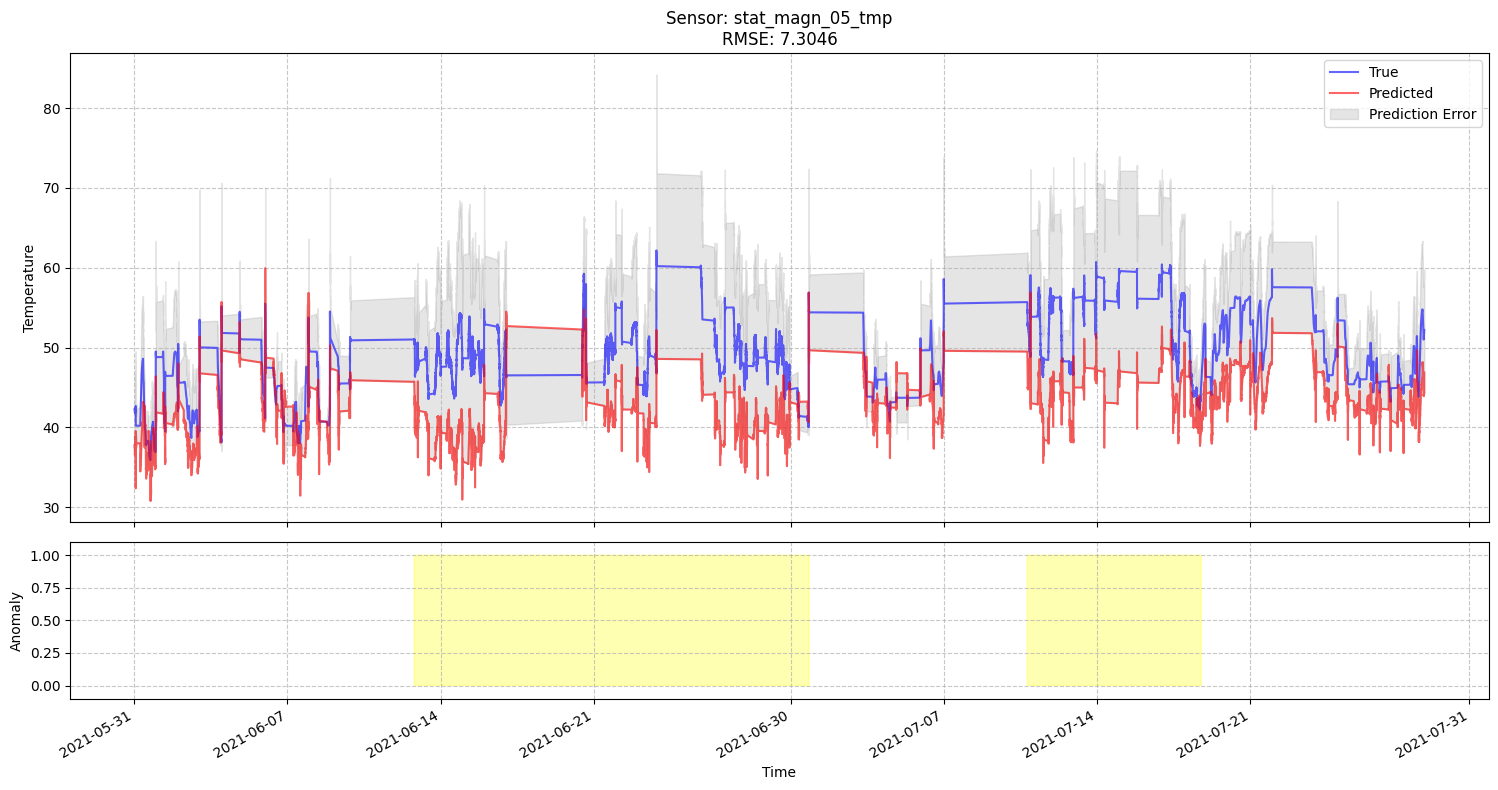


Plotting sensor 23: stat_magn_06_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_06_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


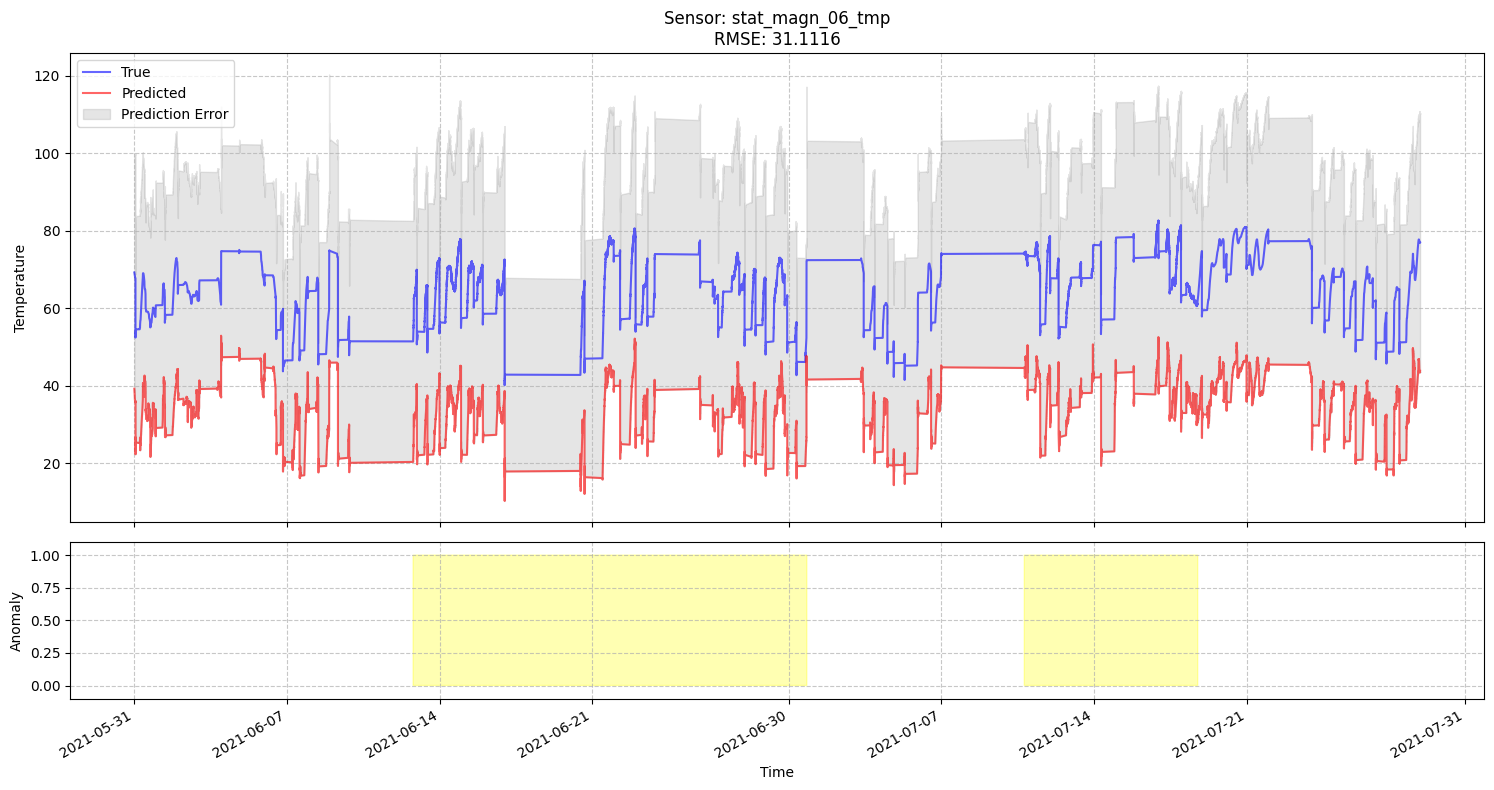


Plotting sensor 24: stat_magn_07_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_07_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


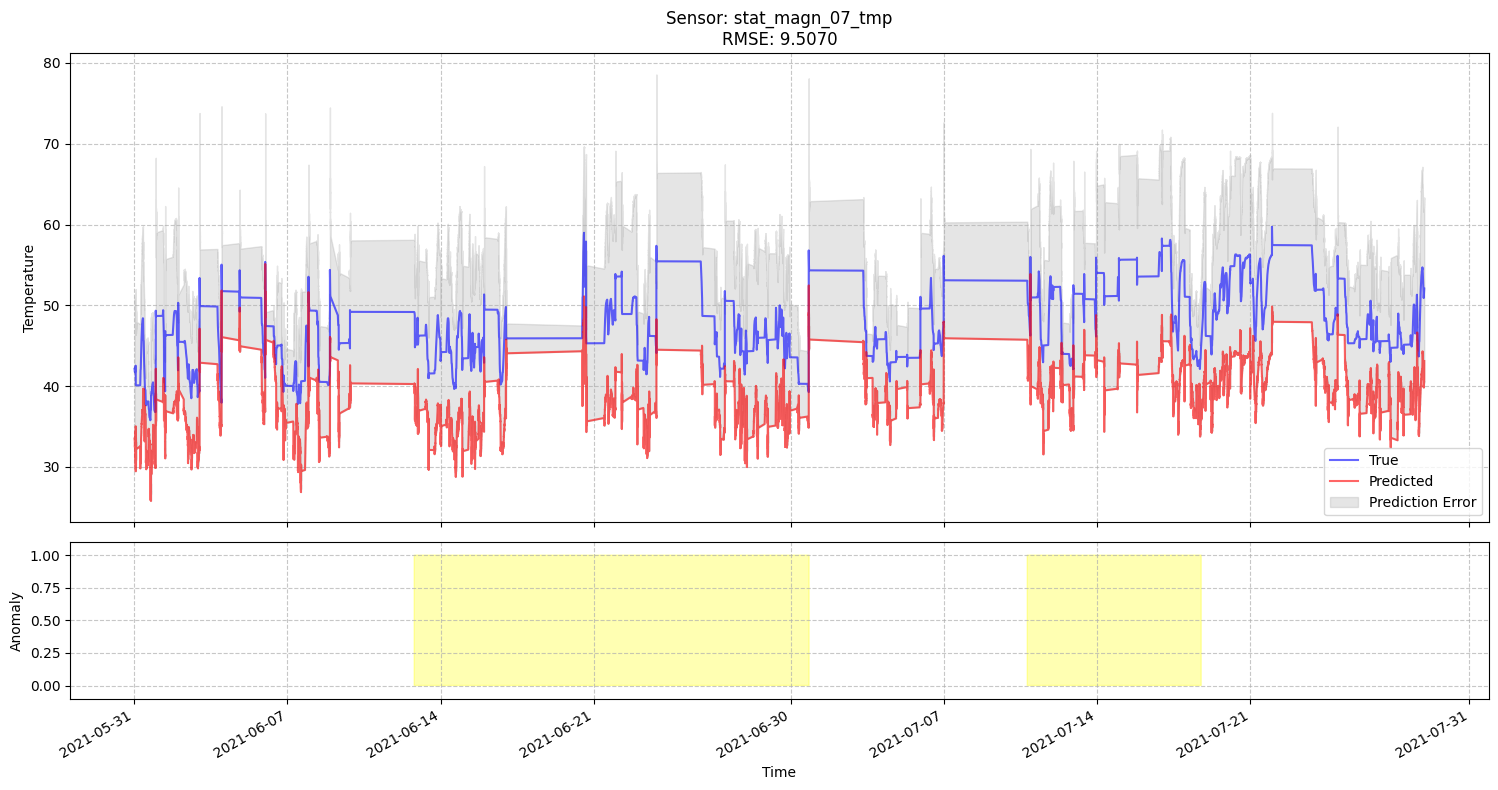


Plotting sensor 25: stat_magn_08_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_08_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


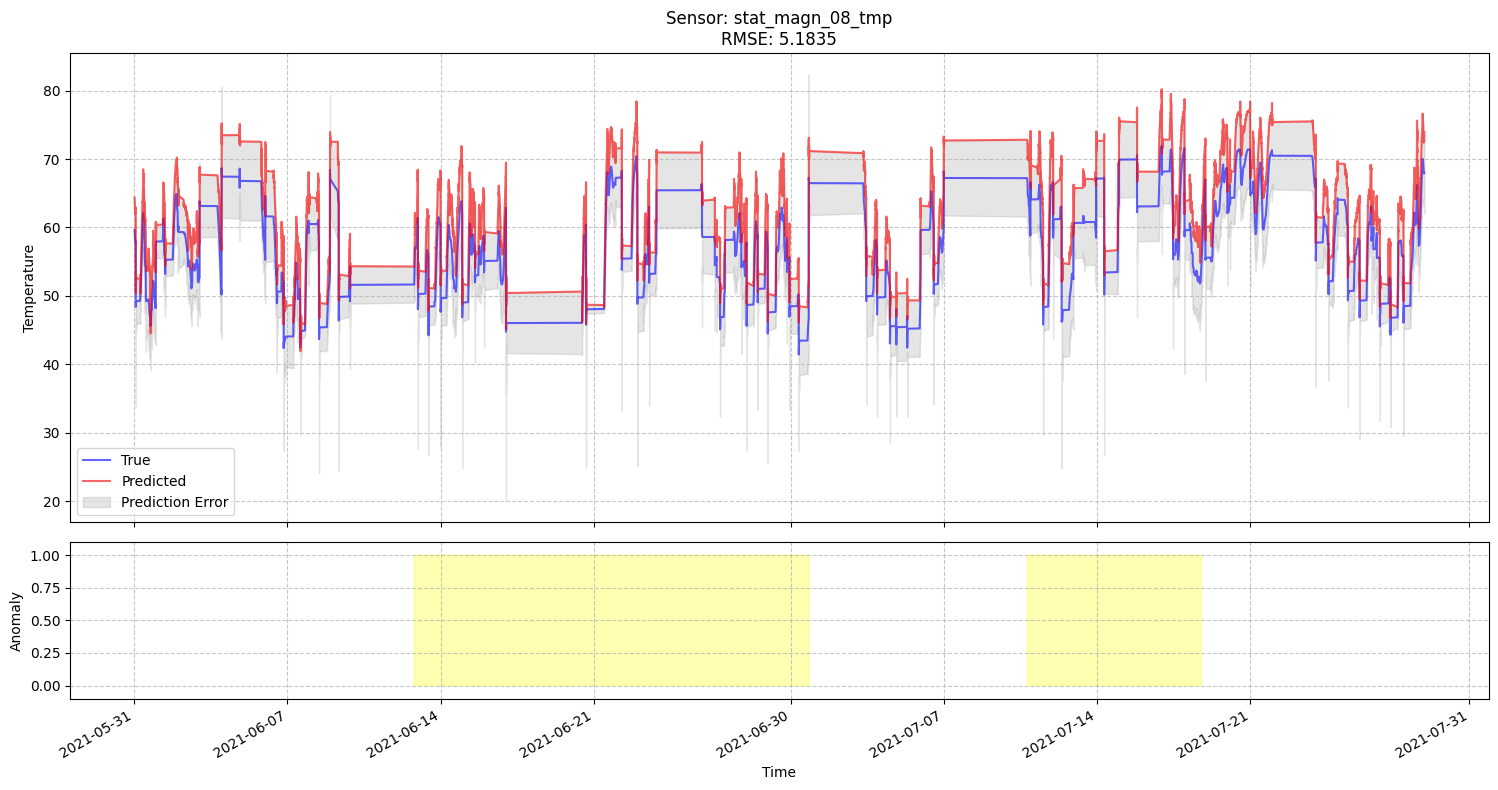


Plotting sensor 26: stat_magn_09_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_09_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


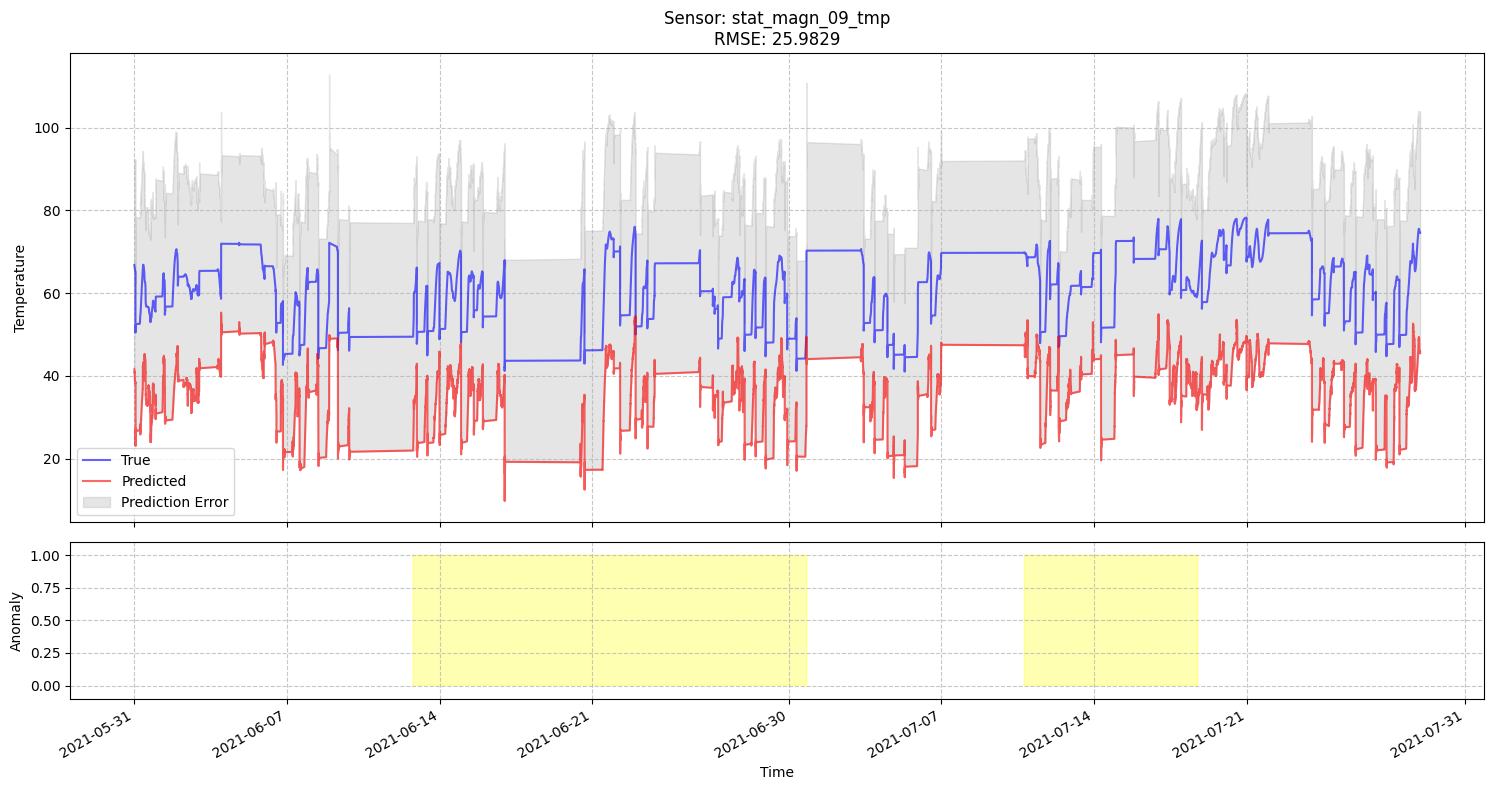


Plotting sensor 27: stat_magn_10_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_10_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


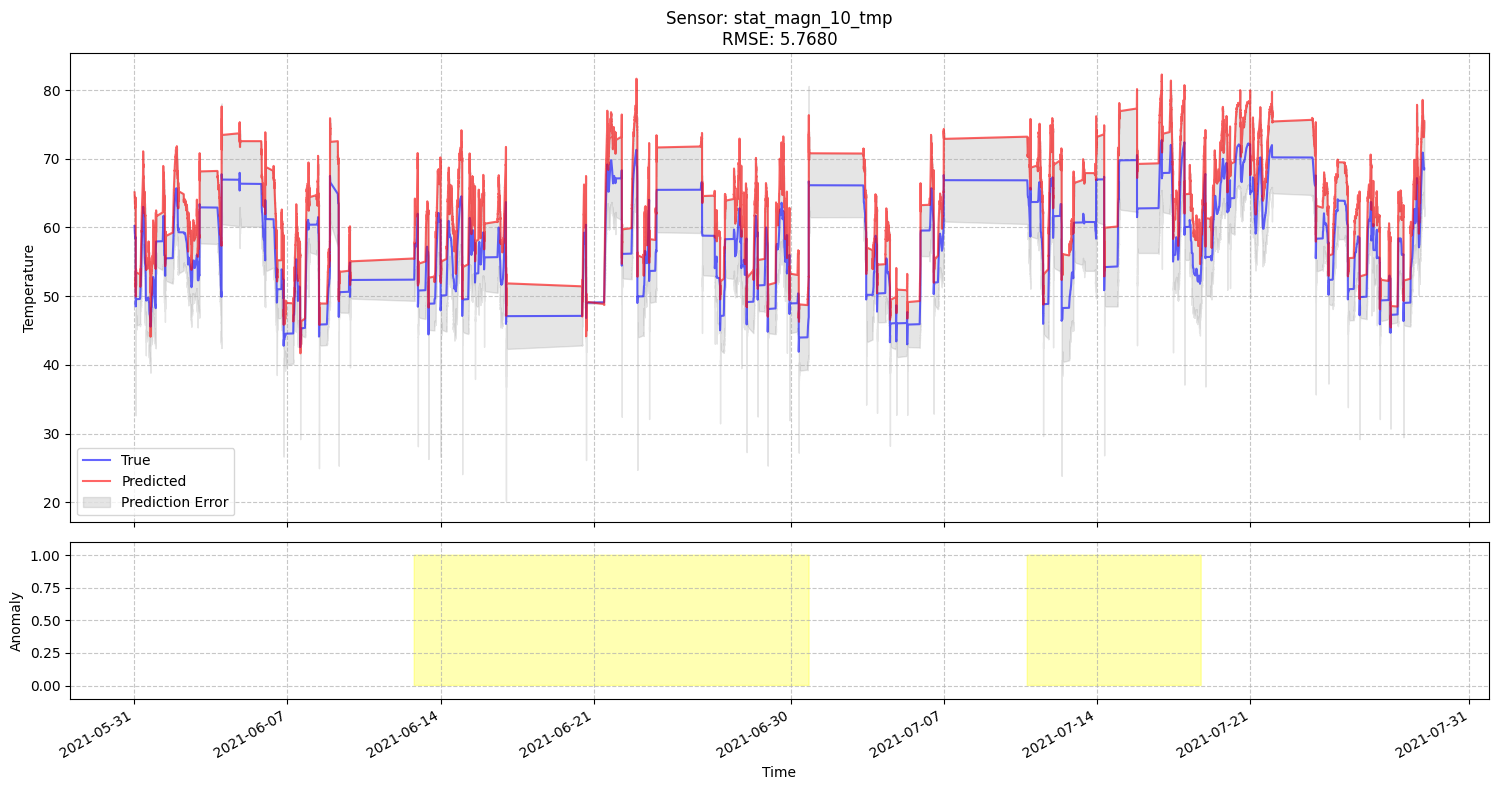


Plotting sensor 28: stat_magn_11_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_11_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


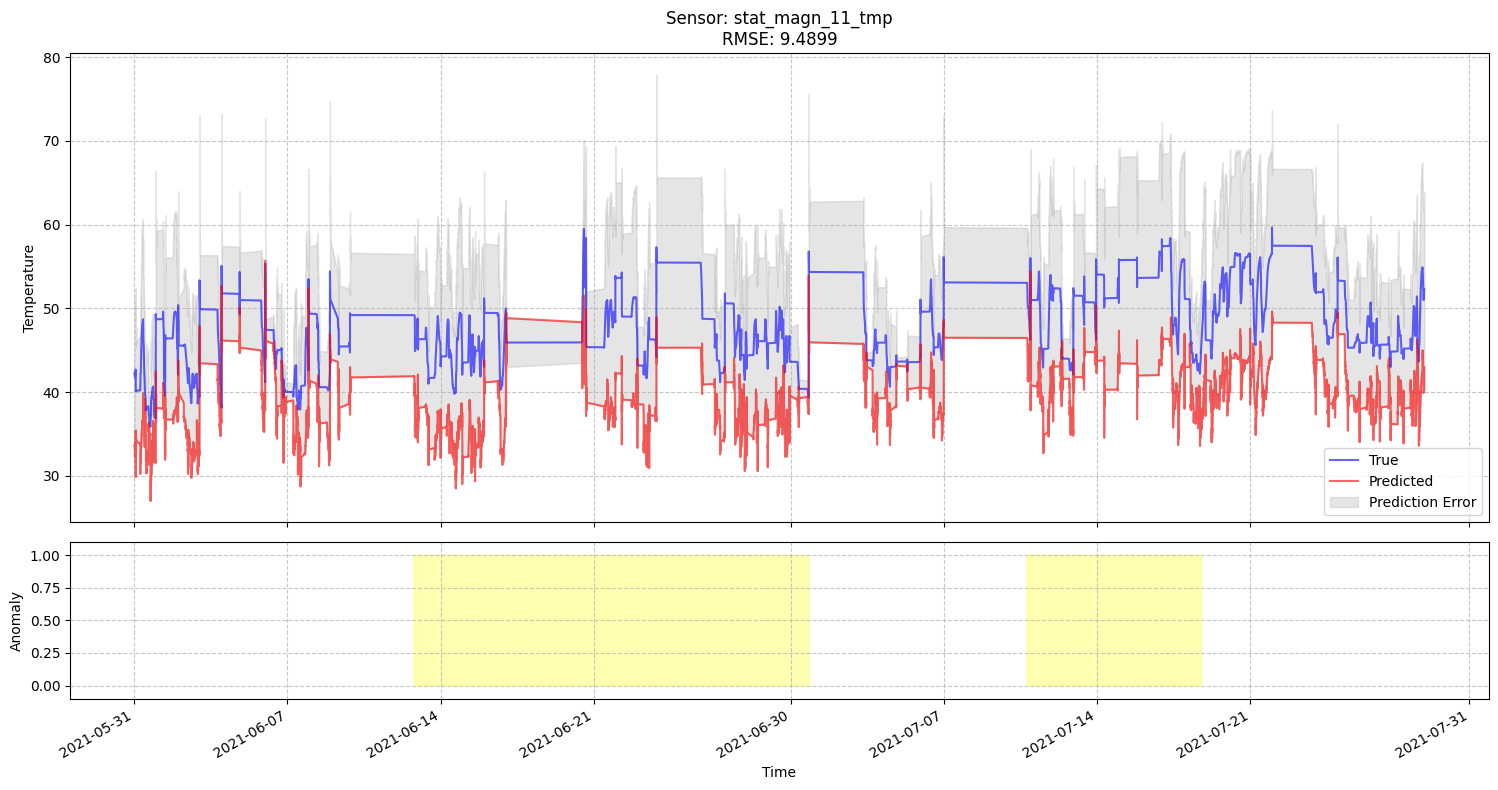


Plotting sensor 29: stat_magn_12_tmp

Plotting ranges:
Sensor data index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:33:30+02:00
Ground truth index range: 2021-06-01 00:16:00+02:00 to 2021-07-29 22:58:30+02:00

Anomaly periods for stat_magn_12_tmp:
First anomaly: 2021-06-13 18:57:30+02:00
Last anomaly: 2021-07-19 17:57:00+02:00
Total anomaly points: 20582


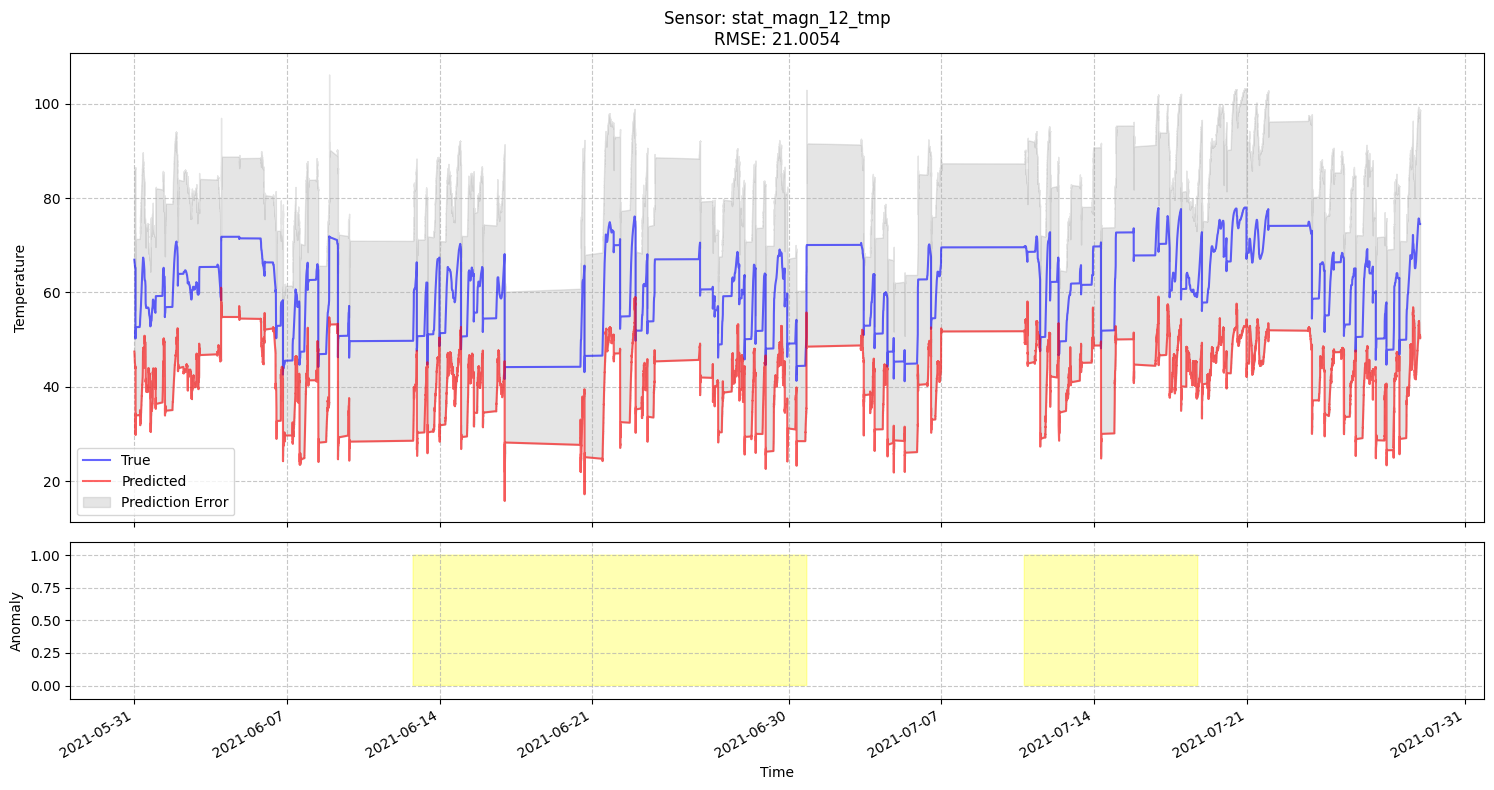

In [157]:
# Define test configuration parameters
TEST_PARAMS = {
    'units': ['VG5', 'VG6'],  # List of units to test
    'test_sets': ['01', '02', '03'],  # List of test sets
    'anomaly_types': ['a', 'b']  # List of anomaly types
}

def create_test_config(unit="VG5", test_set="01", anomaly_type="a"):
    """Create a test configuration dictionary"""
    return {
        'unit': unit,
        'test_set': test_set,
        'anomaly_type': anomaly_type
    }

# Now you can use it:
# First, make sure we have the normalizer from training
train_loader, val_loader, normalizer = setup_training(SELECTED_SENSOR_GROUP, DEFAULT_PARAMS)

# Create test configuration
test_config = create_test_config(unit="VG5", test_set="01", anomaly_type="a")# Print the configuration

print("Test configuration:")
print(test_config)

# Now pass the normalizer and test_config when loading test data
control_test, sensors_test, ground_truth = load_and_preprocess_synthetic_test(
    dataset_root, 
    normalizer,
    test_config
)

# Create test dataset
test_dataset = SlidingWindowDataset(
    control_test, 
    sensors_test,
    window=DEFAULT_PARAMS['window']
)

# Create test loader
test_loader = DataLoader(
    test_dataset, 
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False
)

# Evaluate
df_test, df_metrics = trainer.eval_prediction(test_loader)

# Print metrics
print("\nMetrics:")
print(df_metrics)

# Plot all sensors
plot_all_sensors(df_test, ground_truth)